# Encoding the hierarchical building: a two-tier VSA cascade (and a fully-combined Tier 3 for comparison)

Ground truth was built and visualized in `hierarchical_building.ipynb`
(`BuildingEnv`: rooms containing furniture, with genuinely nested labels --
a point on furniture is simultaneously "in this room" and "on this
furniture"). This notebook encodes it with `MultiScaleFHRRMap`-style
models, three ways:

- **Tier 1 (coarse, one shared memory):** classify room identity
  (`living_room`/`bedroom`/`kitchen`/`bathroom`/`wall`) for any point in the
  building. All 5 categories share one memory and one learned multi-scale
  mixture over length scales `[0.5, 0.2, 0.05]` (re-tuned for room/wall
  sizes here, vs. the original room dataset's `[0.4, 0.15, 0.05]`).
- **Tier 2 (fine, one memory per room):** classify what a point is on --
  `floor` (the open space) or one of that room's furniture items -- as an
  explicit 3-way classification. Each room gets its own clean memory
  (removing room-vs-room crosstalk), but *within* a room, `floor` and its
  2 furniture items share one memory and mixture, over length scales
  `[0.3, 0.15, 0.05]` (re-tuned for furniture sizes, ~0.15-0.5 units). We
  first tried inferring floor from low confidence with no explicit floor
  class, and found it fails badly (a floor query in the bathroom came back
  "tub" at 94% confidence) -- with no floor class to compete against,
  furniture had nothing to lose by claiming the whole room. An explicit
  floor class also reproduces the original room dataset's big-class
  -vs-small-classes setup (floor is ~70-80% of each room), which is what
  gave the multi-scale mixture real competitive pressure to resolve there.
- **Tier 3 (everything, one house-wide memory):** the fully-combined
  design we originally set aside -- one shared memory for the whole house,
  room identity and floor/furniture identity both bound in, each at its
  own multi-scale mixture. Built and compared directly against Tiers 1+2
  after understanding them separately, specifically to measure the
  crosstalk cost of combining everything into one vector.

Querying a position via the two-tier cascade: Tier 1 says which room, then
that room's Tier 2 model says floor or which furniture. Tier 3 answers both
questions from the same single memory.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from multiscalessps.envs.building import make_default_building
from multiscalessps.metrics import kl_divergence

DIM = 1024
SEED = 0
device = "cpu"

building = make_default_building()
H, W = building.grid_size
(xmin, xmax), (ymin, ymax) = building.bounds
extent = (xmin, xmax, ymin, ymax)
eps = 1e-12

positions = building.dense_positions()
xy_all = np.array([p for p, _ in positions], dtype=np.float32)
room_labels_all = np.array([lbl["room"] for _, lbl in positions])
furniture_labels_all = np.array([lbl["furniture"] for _, lbl in positions], dtype=object)

print(f"grid: {building.grid_size}, total cells: {len(xy_all)}")
print(f"rooms: {building.room_names}")
print(f"furniture: {building.furniture_names}")

grid: (128, 128), total cells: 16384
rooms: ['living_room', 'bedroom', 'kitchen', 'bathroom']
furniture: ['sofa', 'tv_stand', 'bed', 'wardrobe', 'table', 'stove', 'sink', 'tub']


## Model and shared helpers

`MultiScaleFHRRMap` is copied verbatim from `multi_scale_learning.ipynb`
(shared memory, class binding, learned multi-scale mixture, temperature
-calibrated `predict_proba`) -- both tiers use it, since Tier 1 needs a
shared memory across rooms and Tier 2 needs a shared memory across a room's
furniture items. The only thing that differs between instances is the
class vocabulary, the length scales, and which points it's trained on.

`make_split`, `train_model`, and `calibrate_temperature` generalize the
per-notebook patterns from `baseline_comparison.ipynb` so the same code
trains and calibrates every one of the 5 models below (1 Tier-1 + 4 Tier-2)
identically.

In [2]:
class MultiScaleFHRRMap(nn.Module):
    """Shared global memory, multi-scale mixture over discrete length scales.
    Copied verbatim from multi_scale_learning.ipynb."""

    def __init__(self, dim, spatial_dim, num_classes, lengthscales, device="cpu"):
        super().__init__()
        self.dim = dim
        self.spatial_dim = spatial_dim
        self.num_classes = num_classes
        self.lengthscales = torch.tensor(lengthscales, device=device).float()
        self.num_scales = len(lengthscales)

        axis_phase = 2 * torch.pi * torch.rand(self.num_scales, spatial_dim, dim, device=device) - torch.pi
        class_phase = 2 * torch.pi * torch.rand(num_classes, dim, device=device) - torch.pi
        scale_phase = 2 * torch.pi * torch.rand(self.num_scales, dim, device=device) - torch.pi

        self.register_buffer("axis_phase", axis_phase)
        self.register_buffer("class_vecs", torch.exp(1j * class_phase))
        self.register_buffer("scale_vecs", torch.exp(1j * scale_phase))

        self.scale_logits = nn.Parameter(torch.zeros(self.num_scales))

    def encode_position(self, x):
        scaled_phase = self.axis_phase / self.lengthscales[:, None, None]
        phase = torch.einsum("nj,kjd->nkd", x, scaled_phase)
        return torch.exp(1j * phase)

    def build_memory(self, points, labels, point_weights=None):
        pos = self.encode_position(points)
        class_vec = self.class_vecs[labels]
        scale_vec = self.scale_vecs
        atoms = pos * class_vec[:, None, :] * scale_vec[None, :, :]
        scale_weights = F.softmax(self.scale_logits, dim=0)
        atoms = atoms * scale_weights[None, :, None]
        if point_weights is not None:
            atoms = atoms * point_weights[:, None, None]
        records = atoms.sum(dim=1)
        memory = records.sum(dim=0)
        return memory / torch.linalg.norm(memory)

    def score_classes(self, memory, query_points):
        pos = self.encode_position(query_points)
        probes = pos[:, :, None, :] * self.scale_vecs[None, :, None, :] * self.class_vecs[None, None, :, :]
        sims = torch.real(
            torch.sum(torch.conj(probes) * memory[None, None, None, :], dim=-1)
        ) / self.dim
        return sims.sum(dim=1)

    def predict_proba(self, memory, query_points, temperature=1.0):
        scores = self.score_classes(memory, query_points) / temperature
        scores = scores - scores.max(dim=-1, keepdim=True).values
        return F.softmax(scores, dim=-1)


def make_split(labels_idx, num_classes, val_frac=0.2, seed=SEED):
    """Stratified train/val split of indices into ``labels_idx``."""
    rng = np.random.default_rng(seed)
    train_idx, val_idx = [], []
    for c in range(num_classes):
        cp = np.flatnonzero(labels_idx == c)
        rng.shuffle(cp)
        n_val = max(1, int(round(val_frac * len(cp))))
        val_idx.append(cp[:n_val])
        train_idx.append(cp[n_val:])
    return np.concatenate(train_idx), np.concatenate(val_idx)


def train_model(model, train_points, train_labels, class_weights, n_epochs=200, lr=0.05, log_mixture=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mixture_history = [] if log_mixture else None
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        memory = model.build_memory(train_points, train_labels)
        scores = model.score_classes(memory, train_points)
        loss = F.cross_entropy(scores, train_labels, weight=class_weights)
        loss.backward()
        optimizer.step()
        if log_mixture:
            mixture_history.append(F.softmax(model.scale_logits, dim=0).detach().numpy().copy())
    with torch.no_grad():
        memory = model.build_memory(train_points, train_labels)
    return memory, (np.array(mixture_history) if log_mixture else None)


def calibrate_temperature(model, memory, val_points_t, val_labels_idx, class_weights_np, temperatures=None):
    if temperatures is None:
        temperatures = np.logspace(-4, 1, 60)
    val_nll = []
    for t in temperatures:
        with torch.no_grad():
            probs = model.predict_proba(memory, val_points_t, temperature=t).numpy()
        logp = np.log(probs[np.arange(len(val_labels_idx)), val_labels_idx] + 1e-12)
        w = class_weights_np[val_labels_idx]
        val_nll.append(-(w * logp).sum() / w.sum())
    return temperatures[int(np.argmin(val_nll))]

In [3]:
class MultiScaleFHRRMapLearnedTemp(MultiScaleFHRRMap):
    """MultiScaleFHRRMap with a learnable temperature folded directly into the
    training loss, mirroring HouseFHRRMapLearnedTemp (Tier 3, below): the raw
    FHRR correlation scores are O(1/sqrt(dim)) in magnitude, so an untempered
    F.cross_entropy sees a near-uniform softmax regardless of which class is
    correct, and scale_logits gets almost no gradient signal."""

    def __init__(self, *args, init_temp=0.01, **kwargs):
        super().__init__(*args, **kwargs)
        self.log_temperature = nn.Parameter(torch.tensor(float(np.log(init_temp))))

    @property
    def temperature(self):
        return torch.exp(self.log_temperature)

    def scaled_scores(self, memory, query_points):
        return self.score_classes(memory, query_points) / self.temperature


def train_model_learned_temp(model, train_points, train_labels, class_weights, n_epochs=200, lr=0.05):
    """Like train_model, but the loss uses model.scaled_scores (temperature folded
    into the loss) instead of raw score_classes. Returns (memory, mixture_history,
    loss_history, temperature_history)."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mixture_history, loss_history, temp_history = [], [], []
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        memory = model.build_memory(train_points, train_labels)
        scores = model.scaled_scores(memory, train_points)
        loss = F.cross_entropy(scores, train_labels, weight=class_weights)
        loss.backward()
        optimizer.step()
        mixture_history.append(F.softmax(model.scale_logits, dim=0).detach().numpy().copy())
        loss_history.append(loss.item())
        temp_history.append(model.temperature.item())
    with torch.no_grad():
        memory = model.build_memory(train_points, train_labels)
    return memory, np.array(mixture_history), loss_history, temp_history

## Tier 1: room identity (coarse, one shared memory)

Trained on all 16,384 grid cells, 5-way classification (4 rooms + wall).

In [4]:
TIER1_LENGTHSCALES = [0.5, 0.2, 0.05]

room_names_t1 = sorted(set(room_labels_all))
room_to_idx_t1 = {name: i for i, name in enumerate(room_names_t1)}
room_idx_all = np.array([room_to_idx_t1[r] for r in room_labels_all])

train_idx1, val_idx1 = make_split(room_idx_all, num_classes=len(room_names_t1))

train_points1 = torch.tensor(xy_all[train_idx1], device=device)
train_labels1 = torch.tensor(room_idx_all[train_idx1], device=device)
val_points1 = torch.tensor(xy_all[val_idx1], device=device)
val_labels1_idx = room_idx_all[val_idx1]

class_counts1 = torch.bincount(train_labels1, minlength=len(room_names_t1)).float()
class_weights1 = class_counts1.sum() / (len(room_names_t1) * class_counts1)
class_weights1_np = class_weights1.numpy()

print(f"Tier 1 classes: {room_names_t1}")
print(f"train points: {len(train_idx1)}, val points: {len(val_idx1)}")

torch.manual_seed(SEED)
model1 = MultiScaleFHRRMap(
    dim=DIM, spatial_dim=2, num_classes=len(room_names_t1), lengthscales=TIER1_LENGTHSCALES, device=device,
)
memory1, mixture_hist1 = train_model(model1, train_points1, train_labels1, class_weights1, log_mixture=True)
temp1 = calibrate_temperature(model1, memory1, val_points1, val_labels1_idx, class_weights1_np)

with torch.no_grad():
    val_probs1 = model1.predict_proba(memory1, val_points1, temperature=temp1).numpy()
val_pred1 = val_probs1.argmax(axis=1)

print(f"\ncalibrated temperature: {temp1:.4g}")
print("learned mixture weights:", dict(zip(["coarse", "medium", "fine"], mixture_hist1[-1].round(3))))
print("\nper-room val recall:")
for name, idx in room_to_idx_t1.items():
    mask = val_labels1_idx == idx
    print(f"  {name:>12s}: {(val_pred1[mask] == idx).mean():.3f}")

Tier 1 classes: [np.str_('bathroom'), np.str_('bedroom'), np.str_('kitchen'), np.str_('living_room'), np.str_('wall')]
train points: 13106, val points: 3278



calibrated temperature: 0.001536
learned mixture weights: {'coarse': np.float32(0.343), 'medium': np.float32(0.322), 'fine': np.float32(0.335)}

per-room val recall:
      bathroom: 0.978
       bedroom: 0.964
       kitchen: 0.963
   living_room: 0.947
          wall: 0.268


### Does the learned-temperature fix change Tier 1's mixture?

Tier 1's `scale_logits` mixture barely moved from uniform under plain
`train_model` (see the takeaway at the end of the notebook). `HouseFHRRMapLearnedTemp`
(Tier 3, below) shows that an untempered `F.cross_entropy` on raw FHRR
scores gives the mixture almost no gradient at all. Retrain Tier 1 with
`MultiScaleFHRRMapLearnedTemp` to check whether "nothing forcing a
resolution" is a real finding about this dataset, or whether it was this
same temperature confound.

In [5]:
torch.manual_seed(SEED)
model1_lt = MultiScaleFHRRMapLearnedTemp(
    dim=DIM, spatial_dim=2, num_classes=len(room_names_t1), lengthscales=TIER1_LENGTHSCALES, device=device,
)
memory1_lt, mixture_hist1_lt, loss_hist1_lt, temp_hist1_lt = train_model_learned_temp(
    model1_lt, train_points1, train_labels1, class_weights1
)

with torch.no_grad():
    val_probs1_lt = model1_lt.predict_proba(
        memory1_lt, val_points1, temperature=model1_lt.temperature.item()
    ).numpy()
val_pred1_lt = val_probs1_lt.argmax(axis=1)

print(f"Tier 1 learned temperature: {model1_lt.temperature.item():.4g}  (post-hoc calibrated: {temp1:.4g})")
print(f"loss: epoch0={loss_hist1_lt[0]:.4f}  epoch199={loss_hist1_lt[-1]:.4f}")
print("mixture (tempered):  ", dict(zip(["coarse", "medium", "fine"], mixture_hist1_lt[-1].round(3))))
print("mixture (untempered):", dict(zip(["coarse", "medium", "fine"], mixture_hist1[-1].round(3))))
print("\nper-room val recall (tempered):")
for name, idx in room_to_idx_t1.items():
    mask = val_labels1_idx == idx
    print(f"  {name:>12s}: {(val_pred1_lt[mask] == idx).mean():.3f}")

Tier 1 learned temperature: 0.001058  (post-hoc calibrated: 0.001536)
loss: epoch0=1.1446  epoch199=0.4205
mixture (tempered):   {'coarse': np.float32(0.094), 'medium': np.float32(0.36), 'fine': np.float32(0.546)}
mixture (untempered): {'coarse': np.float32(0.343), 'medium': np.float32(0.322), 'fine': np.float32(0.335)}

per-room val recall (tempered):
      bathroom: 0.969
       bedroom: 0.930
       kitchen: 0.963
   living_room: 0.961
          wall: 0.355


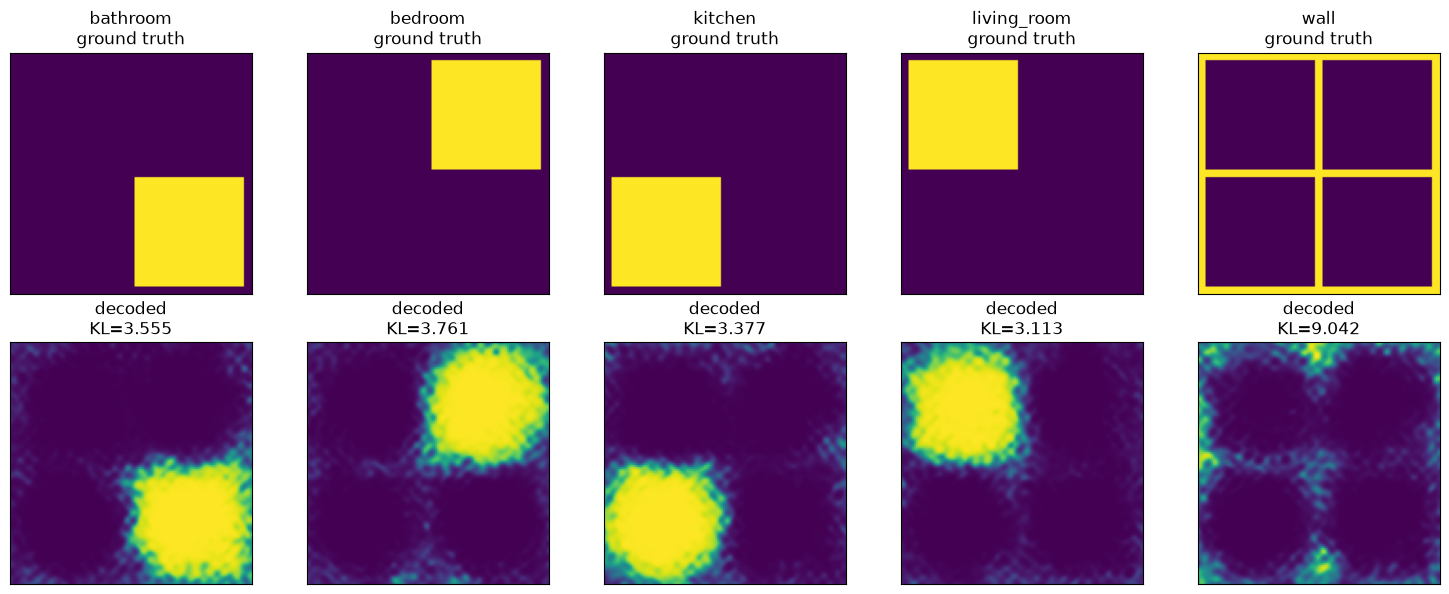

Tier 1 KL: {'bathroom': 3.555, 'bedroom': 3.761, 'kitchen': 3.377, 'living_room': 3.113, 'wall': 9.042}


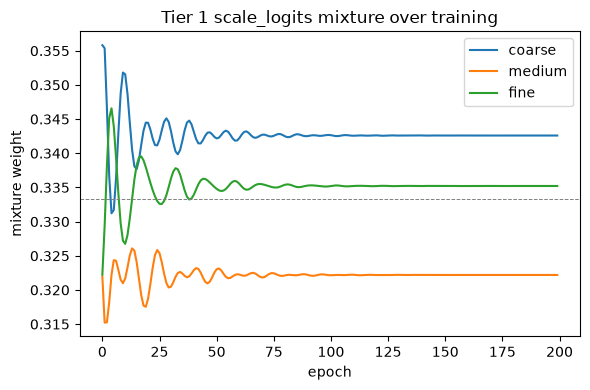

In [6]:
grid_points_t = torch.tensor(xy_all, dtype=torch.float32, device=device)
with torch.no_grad():
    grid_probs1 = model1.predict_proba(memory1, grid_points_t, temperature=temp1).numpy()

gt_maps1 = building.room_probability_maps()
est_maps1 = {}
for name, idx in room_to_idx_t1.items():
    m = grid_probs1[:, idx].reshape(H, W) + eps
    est_maps1[name] = m / m.sum()
kl1 = {name: kl_divergence(est_maps1[name], gt_maps1[name]) for name in gt_maps1}

fig, axes = plt.subplots(2, len(room_names_t1), figsize=(3 * len(room_names_t1), 6))
for col, name in enumerate(room_names_t1):
    axes[0, col].imshow(gt_maps1[name], extent=extent, origin="upper", cmap="viridis")
    axes[0, col].set_title(f"{name}\nground truth")
    axes[1, col].imshow(est_maps1[name], extent=extent, origin="upper", cmap="viridis")
    axes[1, col].set_title(f"decoded\nKL={kl1[name]:.3f}")
    for ax in (axes[0, col], axes[1, col]):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")
fig.tight_layout()
plt.show()

print("Tier 1 KL:", {k: round(v, 3) for k, v in kl1.items()})

fig, ax = plt.subplots(figsize=(6, 4))
for i, name in enumerate(["coarse", "medium", "fine"]):
    ax.plot(mixture_hist1[:, i], label=name)
ax.axhline(1 / 3, color="gray", linestyle="--", linewidth=0.7)
ax.set_xlabel("epoch")
ax.set_ylabel("mixture weight")
ax.set_title("Tier 1 scale_logits mixture over training")
ax.legend()
fig.tight_layout()
plt.show()

## Tier 2: floor / furniture identity (fine, one memory per room)

One `MultiScaleFHRRMap` per room, 3-way classification: `floor` + that
room's 2 furniture items, trained on *every* point in the room (not just
furniture points).

In [7]:
TIER2_LENGTHSCALES = [0.3, 0.15, 0.05]

tier2 = {}  # room_name -> dict with model, memory, temp, furniture_names, mixture_history, kl, est_maps, gt_maps

furniture_maps_gt = building.furniture_probability_maps()

for room_name in building.room_names:
    room_mask_grid_flat = room_labels_all == room_name  # every point in this room: floor + furniture
    xy_room = xy_all[room_mask_grid_flat]
    furn_room_raw = furniture_labels_all[room_mask_grid_flat]
    furn_room = np.array(["floor" if f is None else f for f in furn_room_raw])

    furn_names_room = sorted(set(furn_room), key=lambda n: (n != "floor", n))  # "floor" first
    furn_to_idx_room = {n: i for i, n in enumerate(furn_names_room)}
    furn_idx_room = np.array([furn_to_idx_room[f] for f in furn_room])

    train_idx2, val_idx2 = make_split(furn_idx_room, num_classes=len(furn_names_room))
    train_points2 = torch.tensor(xy_room[train_idx2], device=device)
    train_labels2 = torch.tensor(furn_idx_room[train_idx2], device=device)
    val_points2 = torch.tensor(xy_room[val_idx2], device=device)
    val_labels2_idx = furn_idx_room[val_idx2]

    class_counts2 = torch.bincount(train_labels2, minlength=len(furn_names_room)).float()
    class_weights2 = class_counts2.sum() / (len(furn_names_room) * class_counts2)
    class_weights2_np = class_weights2.numpy()

    torch.manual_seed(SEED)
    model2 = MultiScaleFHRRMap(
        dim=DIM, spatial_dim=2, num_classes=len(furn_names_room), lengthscales=TIER2_LENGTHSCALES, device=device,
    )
    memory2, mixture_hist2 = train_model(model2, train_points2, train_labels2, class_weights2, log_mixture=True)
    temp2 = calibrate_temperature(model2, memory2, val_points2, val_labels2_idx, class_weights2_np)

    with torch.no_grad():
        val_probs2 = model2.predict_proba(memory2, val_points2, temperature=temp2).numpy()
    val_pred2 = val_probs2.argmax(axis=1)
    recall2 = {
        name: float((val_pred2[val_labels2_idx == idx] == idx).mean())
        for name, idx in furn_to_idx_room.items()
    }

    # ground-truth maps for this room: floor (computed here) + its furniture (from BuildingEnv)
    floor_mask_grid = (building.room_grid == room_name) & (building.furniture_grid == "")
    gt_maps_room = {"floor": floor_mask_grid.astype(float) / floor_mask_grid.sum()}
    for name in furn_names_room:
        if name != "floor":
            gt_maps_room[name] = furniture_maps_gt[name]

    with torch.no_grad():
        room_grid_probs = model2.predict_proba(
            memory2, torch.tensor(xy_room, dtype=torch.float32, device=device), temperature=temp2
        ).numpy()

    est_maps2 = {}
    kl2 = {}
    for name, idx in furn_to_idx_room.items():
        full = np.zeros(H * W)
        full[room_mask_grid_flat] = room_grid_probs[:, idx] + eps
        full = full.reshape(H, W)
        est_maps2[name] = full / full.sum()
        kl2[name] = kl_divergence(est_maps2[name], gt_maps_room[name])

    tier2[room_name] = dict(
        model=model2, memory=memory2, temp=temp2, furniture_names=furn_names_room,
        furniture_to_idx=furn_to_idx_room, mixture_history=mixture_hist2,
        recall=recall2, kl=kl2, est_maps=est_maps2, gt_maps=gt_maps_room,
        n_train=len(train_idx2), n_val=len(val_idx2),
    )

    print(f"{room_name:>12s}  classes={furn_names_room}  train={len(train_idx2)} val={len(val_idx2)}  "
          f"temp={temp2:.4g}  mixture={dict(zip(['coarse','medium','fine'], mixture_hist2[-1].round(3)))}")
    print(f"{'':>12s}  recall={ {k: round(v,3) for k,v in recall2.items()} }  KL={ {k: round(v,3) for k,v in kl2.items()} }")

 living_room  classes=[np.str_('floor'), np.str_('sofa'), np.str_('tv_stand')]  train=2692 val=672  temp=0.002759  mixture={'coarse': np.float32(0.215), 'medium': np.float32(0.31), 'fine': np.float32(0.475)}
              recall={np.str_('floor'): 0.973, np.str_('sofa'): 0.928, np.str_('tv_stand'): 0.2}  KL={np.str_('floor'): 1.164, np.str_('sofa'): 7.22, np.str_('tv_stand'): 13.99}


     bedroom  classes=[np.str_('floor'), np.str_('bed'), np.str_('wardrobe')]  train=2692 val=672  temp=0.001536  mixture={'coarse': np.float32(0.276), 'medium': np.float32(0.251), 'fine': np.float32(0.473)}
              recall={np.str_('floor'): 0.927, np.str_('bed'): 0.891, np.str_('wardrobe'): 0.903}  KL={np.str_('floor'): 1.154, np.str_('bed'): 4.407, np.str_('wardrobe'): 3.183}


     kitchen  classes=[np.str_('floor'), np.str_('stove'), np.str_('table')]  train=2691 val=673  temp=0.0008555  mixture={'coarse': np.float32(0.216), 'medium': np.float32(0.266), 'fine': np.float32(0.518)}
              recall={np.str_('floor'): 0.993, np.str_('stove'): 0.897, np.str_('table'): 0.826}  KL={np.str_('floor'): 0.746, np.str_('stove'): 1.052, np.str_('table'): 1.097}


    bathroom  classes=[np.str_('floor'), np.str_('sink'), np.str_('tub')]  train=2691 val=673  temp=0.00227  mixture={'coarse': np.float32(0.244), 'medium': np.float32(0.225), 'fine': np.float32(0.53)}
              recall={np.str_('floor'): 0.936, np.str_('sink'): 0.588, np.str_('tub'): 0.983}  KL={np.str_('floor'): 0.923, np.str_('sink'): 11.605, np.str_('tub'): 4.303}


### Does the learned-temperature fix change Tier 2's mixture?

Every Tier 2 model already converges to a real, consistent mixture under
plain `train_model` (fine scale landing at 47-53%). Retrain each room's
model tempered too, so the final comparison chart isn't mixing tempered
and untempered results across tiers.

In [8]:
tier2_lt = {}  # room_name -> dict with model, memory, mixture_history, loss_history, recall

for room_name in building.room_names:
    room_mask_grid_flat = room_labels_all == room_name
    xy_room = xy_all[room_mask_grid_flat]
    furn_room_raw = furniture_labels_all[room_mask_grid_flat]
    furn_room = np.array(["floor" if f is None else f for f in furn_room_raw])

    furn_names_room = sorted(set(furn_room), key=lambda n: (n != "floor", n))
    furn_to_idx_room = {n: i for i, n in enumerate(furn_names_room)}
    furn_idx_room = np.array([furn_to_idx_room[f] for f in furn_room])

    train_idx2, val_idx2 = make_split(furn_idx_room, num_classes=len(furn_names_room))
    train_points2 = torch.tensor(xy_room[train_idx2], device=device)
    train_labels2 = torch.tensor(furn_idx_room[train_idx2], device=device)
    val_points2 = torch.tensor(xy_room[val_idx2], device=device)
    val_labels2_idx = furn_idx_room[val_idx2]

    class_counts2 = torch.bincount(train_labels2, minlength=len(furn_names_room)).float()
    class_weights2 = class_counts2.sum() / (len(furn_names_room) * class_counts2)

    torch.manual_seed(SEED)
    model2_lt = MultiScaleFHRRMapLearnedTemp(
        dim=DIM, spatial_dim=2, num_classes=len(furn_names_room), lengthscales=TIER2_LENGTHSCALES, device=device,
    )
    memory2_lt, mixture_hist2_lt, loss_hist2_lt, temp_hist2_lt = train_model_learned_temp(
        model2_lt, train_points2, train_labels2, class_weights2
    )

    with torch.no_grad():
        val_probs2_lt = model2_lt.predict_proba(
            memory2_lt, val_points2, temperature=model2_lt.temperature.item()
        ).numpy()
    val_pred2_lt = val_probs2_lt.argmax(axis=1)
    recall2_lt = {
        name: float((val_pred2_lt[val_labels2_idx == idx] == idx).mean())
        for name, idx in furn_to_idx_room.items()
    }

    tier2_lt[room_name] = dict(
        model=model2_lt, memory=memory2_lt, mixture_history=mixture_hist2_lt,
        loss_history=loss_hist2_lt, recall=recall2_lt,
    )

    print(f"{room_name:>12s}  learned_temp={model2_lt.temperature.item():.4g}  "
          f"loss(epoch0->199)={loss_hist2_lt[0]:.4f}->{loss_hist2_lt[-1]:.4f}  "
          f"mixture={dict(zip(['coarse','medium','fine'], mixture_hist2_lt[-1].round(3)))}")
    print(f"{'':>12s}  recall={ {k: round(v,3) for k,v in recall2_lt.items()} }")

 living_room  learned_temp=0.0007027  loss(epoch0->199)=0.8001->0.3105  mixture={'coarse': np.float32(0.001), 'medium': np.float32(0.089), 'fine': np.float32(0.91)}
              recall={np.str_('floor'): 0.941, np.str_('sofa'): 0.964, np.str_('tv_stand'): 0.867}


     bedroom  learned_temp=0.0007512  loss(epoch0->199)=0.6520->0.1621  mixture={'coarse': np.float32(0.023), 'medium': np.float32(0.157), 'fine': np.float32(0.821)}
              recall={np.str_('floor'): 0.94, np.str_('bed'): 0.953, np.str_('wardrobe'): 0.935}


     kitchen  learned_temp=0.0007485  loss(epoch0->199)=0.7448->0.1261  mixture={'coarse': np.float32(0.041), 'medium': np.float32(0.104), 'fine': np.float32(0.855)}
              recall={np.str_('floor'): 0.978, np.str_('stove'): 1.0, np.str_('table'): 0.87}


    bathroom  learned_temp=0.0009786  loss(epoch0->199)=0.6902->0.2000  mixture={'coarse': np.float32(0.034), 'medium': np.float32(0.096), 'fine': np.float32(0.87)}
              recall={np.str_('floor'): 0.906, np.str_('sink'): 0.824, np.str_('tub'): 0.967}


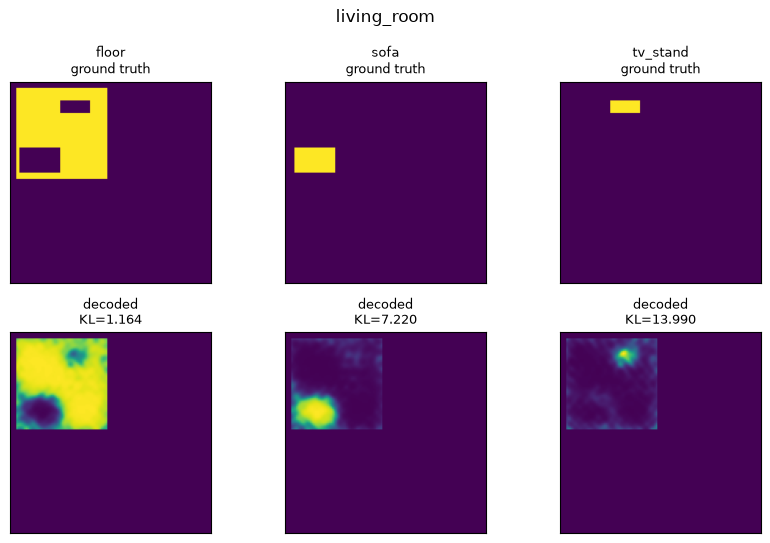

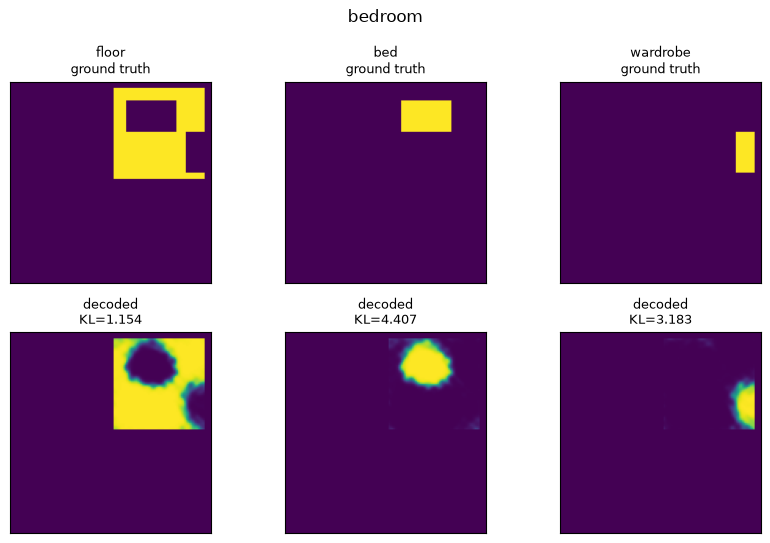

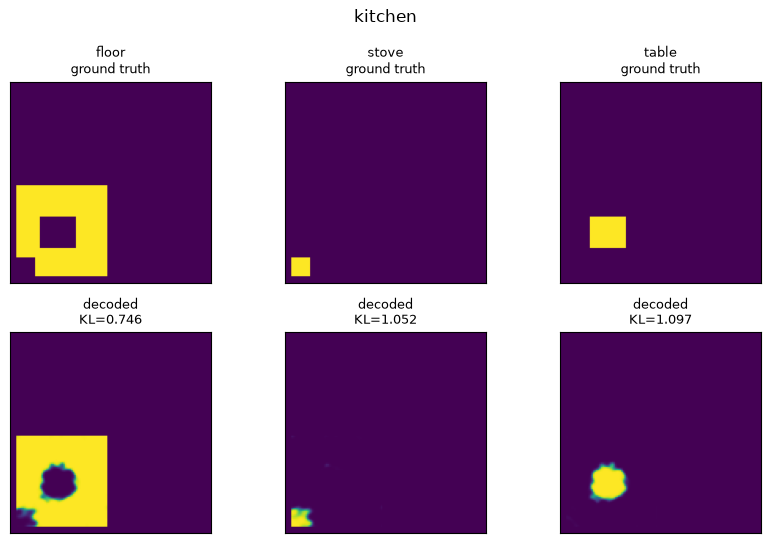

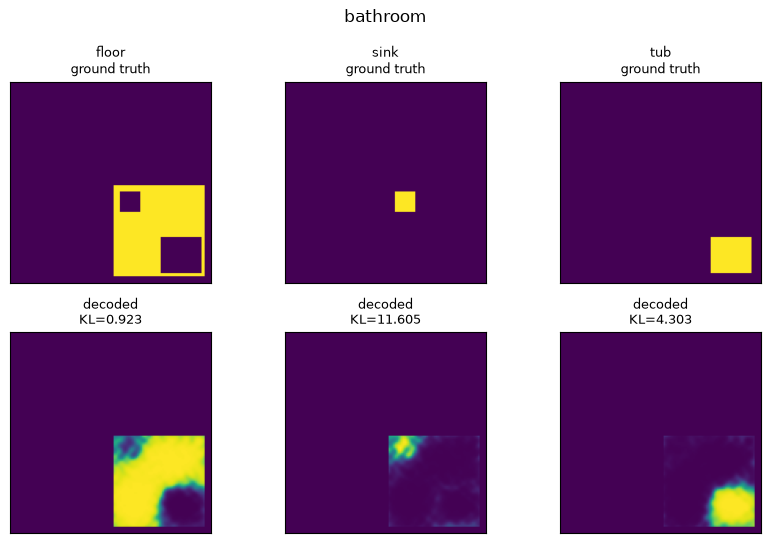

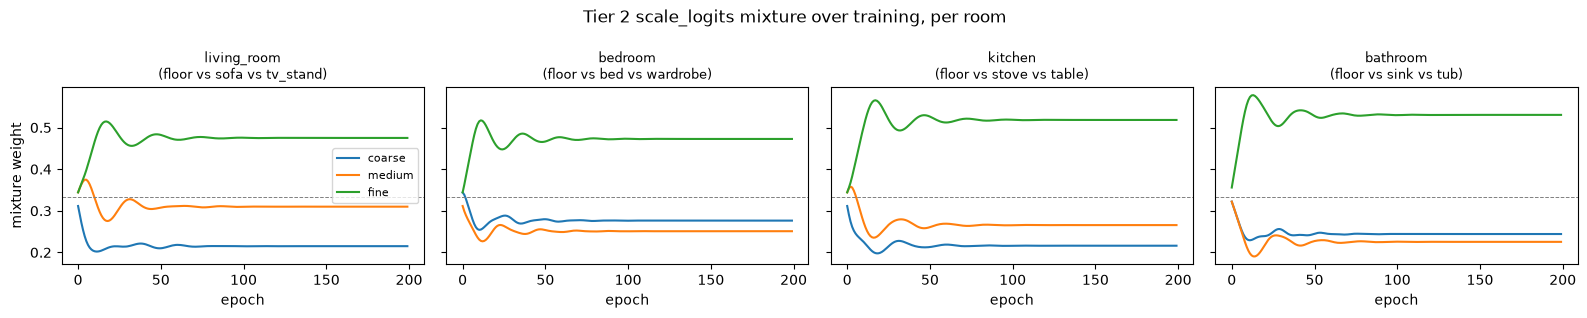

In [9]:
for room_name in building.room_names:
    d = tier2[room_name]
    names = d["furniture_names"]  # "floor" first, then that room's furniture
    fig, axes = plt.subplots(2, len(names), figsize=(2.8 * len(names), 5.5))
    for col, name in enumerate(names):
        axes[0, col].imshow(d["gt_maps"][name], extent=extent, origin="upper", cmap="viridis")
        axes[0, col].set_title(f"{name}\nground truth", fontsize=9)
        axes[1, col].imshow(d["est_maps"][name], extent=extent, origin="upper", cmap="viridis")
        axes[1, col].set_title(f"decoded\nKL={d['kl'][name]:.3f}", fontsize=9)
        for ax in (axes[0, col], axes[1, col]):
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_aspect("equal")
    fig.suptitle(room_name)
    fig.tight_layout()
    plt.show()

fig, axes = plt.subplots(1, len(building.room_names), figsize=(4 * len(building.room_names), 3.2), sharey=True)
for ax, room_name in zip(axes, building.room_names):
    hist = tier2[room_name]["mixture_history"]
    for i, name in enumerate(["coarse", "medium", "fine"]):
        ax.plot(hist[:, i], label=name)
    ax.axhline(1 / 3, color="gray", linestyle="--", linewidth=0.7)
    ax.set_title(f"{room_name}\n({' vs '.join(tier2[room_name]['furniture_names'])})", fontsize=9)
    ax.set_xlabel("epoch")
axes[0].set_ylabel("mixture weight")
axes[0].legend(fontsize=8)
fig.suptitle("Tier 2 scale_logits mixture over training, per room")
fig.tight_layout()
plt.show()

## The cascade: room, then floor/furniture

Given a raw position, query Tier 1 for the room, then that room's Tier 2
model for floor or furniture -- now a plain argmax over an explicit
3-way classification, no confidence-threshold heuristic needed.

                 center of the bed
                                    truth: room='bedroom'      furniture='bed'
                                    pred:  room=np.str_('bedroom') furniture=np.str_('bed')  (confidence=1.00)
         open floor in the bedroom
                                    truth: room='bedroom'      furniture=None
                                    pred:  room=np.str_('wall') furniture=None  (confidence=n/a)
              on the kitchen table
                                    truth: room='kitchen'      furniture='table'
                                    pred:  room=np.str_('kitchen') furniture=np.str_('table')  (confidence=1.00)
  wall between living_room/bedroom
                                    truth: room='wall'         furniture=None
                                    pred:  room=np.str_('bedroom') furniture=None  (confidence=0.96)
                        on the tub
                                    truth: room='bathroom'     furniture='tub'
        

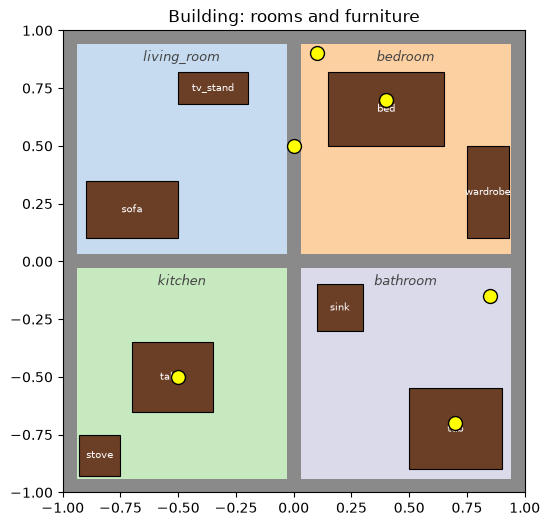

In [10]:
def query_cascade(x, y):
    point = torch.tensor([[x, y]], dtype=torch.float32, device=device)
    with torch.no_grad():
        room_probs = model1.predict_proba(memory1, point, temperature=temp1).numpy()[0]
    room_pred = room_names_t1[int(room_probs.argmax())]

    if room_pred not in tier2:
        return {"room": room_pred, "furniture": None, "confidence": None}

    d = tier2[room_pred]
    with torch.no_grad():
        furn_probs = d["model"].predict_proba(d["memory"], point, temperature=d["temp"]).numpy()[0]
    idx = int(furn_probs.argmax())
    name = d["furniture_names"][idx]
    conf = float(furn_probs[idx])
    furniture_pred = None if name == "floor" else name
    return {"room": room_pred, "furniture": furniture_pred, "confidence": conf}


example_points = {
    "center of the bed": (0.4, 0.7),
    "open floor in the bedroom": (0.1, 0.9),
    "on the kitchen table": (-0.5, -0.5),
    "wall between living_room/bedroom": (0.0, 0.5),
    "on the tub": (0.7, -0.7),
    "open floor in the bathroom": (0.85, -0.15),
}

fig, ax = plt.subplots(figsize=(6, 6))
building.render(ax=ax)
for name, (x, y) in example_points.items():
    truth = building.label_at(x, y)
    pred = query_cascade(x, y)
    ax.plot(x, y, marker="o", markersize=10, color="yellow", markeredgecolor="black", zorder=5)
    conf_str = f"{pred['confidence']:.2f}" if pred["confidence"] is not None else "n/a"
    print(f"{name:>34s}")
    print(f"{'':>34s}  truth: room={truth['room']!r:14s} furniture={truth['furniture']!r}")
    print(f"{'':>34s}  pred:  room={pred['room']!r:14s} furniture={pred['furniture']!r}  (confidence={conf_str})")
plt.show()

## Tier 3: everything combined into one house-wide memory

Back at the planning stage, we considered a fully global design -- one
shared memory for the whole house, where every point is bound with its
room identity at a coarse scale *and*, if it's not a wall, its
floor/furniture identity at a fine scale, both superposed into the same
vector -- and set it aside in favor of the two-tier cascade so we wouldn't
conflate room-vs-room crosstalk with genuine resolution competition. Now
that both tiers are understood on their own, it's worth actually building
that design and comparing: does combining everything into one vector cost
anything relative to keeping the tiers separate?

`HouseFHRRMap` has two independent binding/scoring paths (`_room` and
`_furniture`, each with its own multi-scale mixture) sharing one memory:
`memory = room_records.sum() + furniture_records.sum()`, then normalized
once. Room labels use all 16,384 points (reusing Tier 1's exact split);
floor/furniture labels use all non-wall points with one **global**
9-way vocabulary (`floor` + all 8 furniture items across every room, not
per-room this time). Both heads are trained jointly, one combined loss.

In [11]:
class HouseFHRRMap(nn.Module):
    """One shared memory for the whole house: every point is bound with its
    room identity at a coarse scale; non-wall points are ALSO bound with
    their floor/furniture identity at a fine scale. Both superposed into
    ONE memory, each with its own independent multi-scale mixture."""

    def __init__(self, dim, spatial_dim, num_rooms, num_furniture,
                 room_lengthscales, furniture_lengthscales, device="cpu"):
        super().__init__()
        self.dim = dim
        self.room_lengthscales = torch.tensor(room_lengthscales, device=device).float()
        self.furniture_lengthscales = torch.tensor(furniture_lengthscales, device=device).float()
        self.n_room_scales = len(room_lengthscales)
        self.n_furn_scales = len(furniture_lengthscales)

        room_axis_phase = 2 * torch.pi * torch.rand(self.n_room_scales, spatial_dim, dim, device=device) - torch.pi
        furn_axis_phase = 2 * torch.pi * torch.rand(self.n_furn_scales, spatial_dim, dim, device=device) - torch.pi
        room_phase = 2 * torch.pi * torch.rand(num_rooms, dim, device=device) - torch.pi
        furn_phase = 2 * torch.pi * torch.rand(num_furniture, dim, device=device) - torch.pi
        room_scale_phase = 2 * torch.pi * torch.rand(self.n_room_scales, dim, device=device) - torch.pi
        furn_scale_phase = 2 * torch.pi * torch.rand(self.n_furn_scales, dim, device=device) - torch.pi

        self.register_buffer("room_axis_phase", room_axis_phase)
        self.register_buffer("furn_axis_phase", furn_axis_phase)
        self.register_buffer("room_vecs", torch.exp(1j * room_phase))
        self.register_buffer("furn_vecs", torch.exp(1j * furn_phase))
        self.register_buffer("room_scale_vecs", torch.exp(1j * room_scale_phase))
        self.register_buffer("furn_scale_vecs", torch.exp(1j * furn_scale_phase))

        self.room_scale_logits = nn.Parameter(torch.zeros(self.n_room_scales))
        self.furn_scale_logits = nn.Parameter(torch.zeros(self.n_furn_scales))

    def encode_room_position(self, x):
        scaled_phase = self.room_axis_phase / self.room_lengthscales[:, None, None]
        phase = torch.einsum("nj,kjd->nkd", x, scaled_phase)
        return torch.exp(1j * phase)

    def encode_furniture_position(self, x):
        scaled_phase = self.furn_axis_phase / self.furniture_lengthscales[:, None, None]
        phase = torch.einsum("nj,kjd->nkd", x, scaled_phase)
        return torch.exp(1j * phase)

    def build_memory(self, room_points, room_labels, furn_points, furn_labels):
        pos_r = self.encode_room_position(room_points)
        room_vec = self.room_vecs[room_labels]
        room_w = F.softmax(self.room_scale_logits, dim=0)
        atoms_r = pos_r * room_vec[:, None, :] * self.room_scale_vecs[None, :, :] * room_w[None, :, None]
        records_r = atoms_r.sum(dim=1).sum(dim=0)

        pos_f = self.encode_furniture_position(furn_points)
        furn_vec = self.furn_vecs[furn_labels]
        furn_w = F.softmax(self.furn_scale_logits, dim=0)
        atoms_f = pos_f * furn_vec[:, None, :] * self.furn_scale_vecs[None, :, :] * furn_w[None, :, None]
        records_f = atoms_f.sum(dim=1).sum(dim=0)

        memory = records_r + records_f
        return memory / torch.linalg.norm(memory)

    def score_rooms(self, memory, query_points, chunk_size=1024):
        # Chunked over query points: probes is [chunk, K, C, D], which at large
        # dim/large C can be huge (e.g. 10765 x 3 x 9 x 8192 complex64 ~= 19GB
        # unchunked -- this is what crashed the kernel at dim=8192). Bounding
        # the chunk keeps peak memory independent of the total point count.
        outs = []
        for i in range(0, query_points.shape[0], chunk_size):
            chunk = query_points[i : i + chunk_size]
            pos = self.encode_room_position(chunk)
            probes = pos[:, :, None, :] * self.room_scale_vecs[None, :, None, :] * self.room_vecs[None, None, :, :]
            sims = torch.real(torch.sum(torch.conj(probes) * memory[None, None, None, :], dim=-1)) / self.dim
            outs.append(sims.sum(dim=1))
        return torch.cat(outs, dim=0)

    def score_furniture(self, memory, query_points, chunk_size=1024):
        outs = []
        for i in range(0, query_points.shape[0], chunk_size):
            chunk = query_points[i : i + chunk_size]
            pos = self.encode_furniture_position(chunk)
            probes = pos[:, :, None, :] * self.furn_scale_vecs[None, :, None, :] * self.furn_vecs[None, None, :, :]
            sims = torch.real(torch.sum(torch.conj(probes) * memory[None, None, None, :], dim=-1)) / self.dim
            outs.append(sims.sum(dim=1))
        return torch.cat(outs, dim=0)

    def predict_proba_room(self, memory, query_points, temperature=1.0):
        scores = self.score_rooms(memory, query_points) / temperature
        scores = scores - scores.max(dim=-1, keepdim=True).values
        return F.softmax(scores, dim=-1)

    def predict_proba_furniture(self, memory, query_points, temperature=1.0):
        scores = self.score_furniture(memory, query_points) / temperature
        scores = scores - scores.max(dim=-1, keepdim=True).values
        return F.softmax(scores, dim=-1)


def calibrate_temperature_fn(predict_fn, val_points_t, val_labels_idx, class_weights_np, temperatures=None):
    """Like calibrate_temperature, but takes a bound predict_fn(points, temperature)
    directly -- needed here since HouseFHRRMap has two different predict heads."""
    if temperatures is None:
        temperatures = np.logspace(-4, 1, 60)
    val_nll = []
    for t in temperatures:
        with torch.no_grad():
            probs = predict_fn(val_points_t, temperature=t).numpy()
        logp = np.log(probs[np.arange(len(val_labels_idx)), val_labels_idx] + 1e-12)
        w = class_weights_np[val_labels_idx]
        val_nll.append(-(w * logp).sum() / w.sum())
    return temperatures[int(np.argmin(val_nll))]

In [12]:
# Global floor/furniture vocabulary over all non-wall points (unlike Tier 2, not per-room).
non_wall_mask = room_labels_all != "wall"
xy_nonwall = xy_all[non_wall_mask]
furn_or_floor_all = np.array(["floor" if f is None else f for f in furniture_labels_all[non_wall_mask]])
furn_names_t3 = sorted(set(furn_or_floor_all), key=lambda n: (n != "floor", n))
furn_to_idx_t3 = {n: i for i, n in enumerate(furn_names_t3)}
furn_idx_nonwall = np.array([furn_to_idx_t3[f] for f in furn_or_floor_all])

train_idx3f, val_idx3f = make_split(furn_idx_nonwall, num_classes=len(furn_names_t3))
train_points3f = torch.tensor(xy_nonwall[train_idx3f], device=device)
train_labels3f = torch.tensor(furn_idx_nonwall[train_idx3f], device=device)
val_points3f = torch.tensor(xy_nonwall[val_idx3f], device=device)
val_labels3f_idx = furn_idx_nonwall[val_idx3f]

class_counts3f = torch.bincount(train_labels3f, minlength=len(furn_names_t3)).float()
class_weights3f = class_counts3f.sum() / (len(furn_names_t3) * class_counts3f)
class_weights3f_np = class_weights3f.numpy()

print(f"Tier 3 furniture classes (global): {furn_names_t3}")
print(f"train points: {len(train_idx3f)}, val points: {len(val_idx3f)}")

# Room task reuses Tier 1's exact data/split (train_points1, train_labels1, class_weights1, ...).
torch.manual_seed(SEED)
model3 = HouseFHRRMap(
    dim=DIM, spatial_dim=2, num_rooms=len(room_names_t1), num_furniture=len(furn_names_t3),
    room_lengthscales=TIER1_LENGTHSCALES, furniture_lengthscales=TIER2_LENGTHSCALES, device=device,
)
optimizer = torch.optim.Adam(model3.parameters(), lr=0.05)
room_mix_hist3, furn_mix_hist3 = [], []
room_loss_hist3, furn_loss_hist3, total_loss_hist3 = [], [], []
for epoch in range(200):
    optimizer.zero_grad()
    memory = model3.build_memory(train_points1, train_labels1, train_points3f, train_labels3f)
    room_scores = model3.score_rooms(memory, train_points1)
    furn_scores = model3.score_furniture(memory, train_points3f)
    room_loss = F.cross_entropy(room_scores, train_labels1, weight=class_weights1)
    furn_loss = F.cross_entropy(furn_scores, train_labels3f, weight=class_weights3f)
    loss = room_loss + furn_loss
    loss.backward()
    optimizer.step()
    room_mix_hist3.append(F.softmax(model3.room_scale_logits, dim=0).detach().numpy().copy())
    furn_mix_hist3.append(F.softmax(model3.furn_scale_logits, dim=0).detach().numpy().copy())
    room_loss_hist3.append(room_loss.item())
    furn_loss_hist3.append(furn_loss.item())
    total_loss_hist3.append(loss.item())

room_mix_hist3 = np.array(room_mix_hist3)
furn_mix_hist3 = np.array(furn_mix_hist3)

with torch.no_grad():
    memory3 = model3.build_memory(train_points1, train_labels1, train_points3f, train_labels3f)

temp3_room = calibrate_temperature_fn(
    lambda p, temperature: model3.predict_proba_room(memory3, p, temperature),
    val_points1, val_labels1_idx, class_weights1_np,
)
temp3_furn = calibrate_temperature_fn(
    lambda p, temperature: model3.predict_proba_furniture(memory3, p, temperature),
    val_points3f, val_labels3f_idx, class_weights3f_np,
)

with torch.no_grad():
    val_probs_room3 = model3.predict_proba_room(memory3, val_points1, temperature=temp3_room).numpy()
    val_probs_furn3 = model3.predict_proba_furniture(memory3, val_points3f, temperature=temp3_furn).numpy()
val_pred_room3 = val_probs_room3.argmax(axis=1)
val_pred_furn3 = val_probs_furn3.argmax(axis=1)

print(f"\ntemp3_room={temp3_room:.4g}  temp3_furn={temp3_furn:.4g}")
print("final room mixture:", dict(zip(["coarse", "medium", "fine"], room_mix_hist3[-1].round(3))))
print("final furniture mixture:", dict(zip(["coarse", "medium", "fine"], furn_mix_hist3[-1].round(3))))

print("\nroom recall, Tier 3 vs Tier 1:")
for name, idx in room_to_idx_t1.items():
    mask = val_labels1_idx == idx
    print(f"  {name:>12s}: tier3={(val_pred_room3[mask] == idx).mean():.3f}  tier1={(val_pred1[mask] == idx).mean():.3f}")

print("\nfurniture recall, Tier 3 (global) vs Tier 2 (per-room):")
tier2_recall_lookup = {name: d["recall"][name] for d in tier2.values() for name in d["recall"]}
for name, idx in furn_to_idx_t3.items():
    mask = val_labels3f_idx == idx
    r3 = (val_pred_furn3[mask] == idx).mean()
    print(f"  {name:>10s}: tier3={r3:.3f}  tier2={tier2_recall_lookup[name]:.3f}")

Tier 3 furniture classes (global): [np.str_('floor'), np.str_('bed'), np.str_('sink'), np.str_('sofa'), np.str_('stove'), np.str_('table'), np.str_('tub'), np.str_('tv_stand'), np.str_('wardrobe')]
train points: 10765, val points: 2691



temp3_room=0.001536  temp3_furn=0.00104
final room mixture: {'coarse': np.float32(0.306), 'medium': np.float32(0.344), 'fine': np.float32(0.351)}
final furniture mixture: {'coarse': np.float32(0.28), 'medium': np.float32(0.478), 'fine': np.float32(0.242)}

room recall, Tier 3 vs Tier 1:
      bathroom: tier3=0.932  tier1=0.978
       bedroom: tier3=0.994  tier1=0.964
       kitchen: tier3=0.957  tier1=0.963
   living_room: tier3=0.984  tier1=0.947
          wall: tier3=0.143  tier1=0.268

furniture recall, Tier 3 (global) vs Tier 2 (per-room):
       floor: tier3=0.663  tier2=0.936
         bed: tier3=0.742  tier2=0.891
        sink: tier3=0.618  tier2=0.588
        sofa: tier3=0.554  tier2=0.928
       stove: tier3=0.034  tier2=0.897
       table: tier3=0.750  tier2=0.826
         tub: tier3=0.817  tier2=0.983
    tv_stand: tier3=0.167  tier2=0.200
    wardrobe: tier3=0.226  tier2=0.903


### Room vs. furniture loss during training

Both losses are summed into one scalar for `loss.backward()`, so it's worth
checking whether one dominates the combined gradient or they're both
actually contributing. The 9-way furniture loss and 5-way room loss aren't
on the same natural scale (different number of classes, different
class-weight magnitudes), so a log-scale view alongside the linear one
helps confirm the smaller-looking curve is still moving, not stalled.

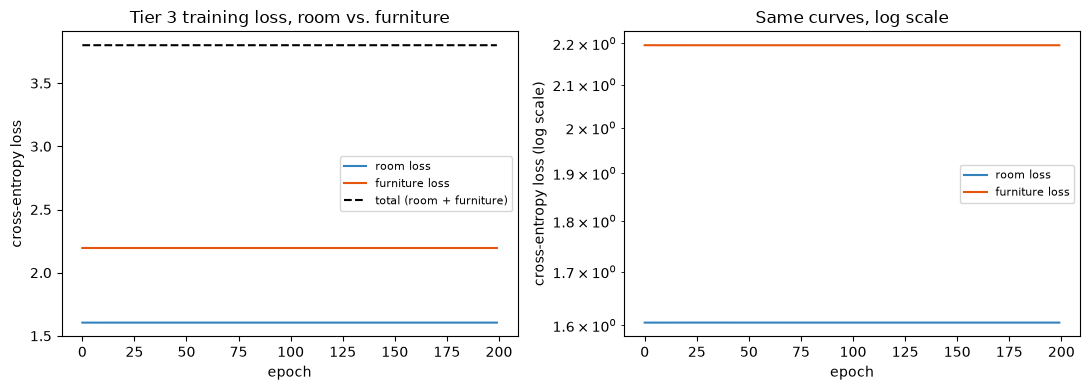

room loss:      epoch 0 = 1.6048   epoch 199 = 1.6048
furniture loss: epoch 0 = 2.1955   epoch 199 = 2.1954
total loss:     epoch 0 = 3.8002   epoch 199 = 3.8002


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(room_loss_hist3, label="room loss", color="#3182bd")
axes[0].plot(furn_loss_hist3, label="furniture loss", color="#e6550d")
axes[0].plot(total_loss_hist3, label="total (room + furniture)", color="black", linewidth=1.5, linestyle="--")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy loss")
axes[0].set_title("Tier 3 training loss, room vs. furniture")
axes[0].legend(fontsize=8)

# log-scale view: the two losses start at very different scales (5-way vs.
# 9-way classification, different class-weight magnitudes), so a linear axis
# can hide whether the smaller one is still moving.
axes[1].plot(room_loss_hist3, label="room loss", color="#3182bd")
axes[1].plot(furn_loss_hist3, label="furniture loss", color="#e6550d")
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("cross-entropy loss (log scale)")
axes[1].set_title("Same curves, log scale")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

print(f"room loss:      epoch 0 = {room_loss_hist3[0]:.4f}   epoch 199 = {room_loss_hist3[-1]:.4f}")
print(f"furniture loss: epoch 0 = {furn_loss_hist3[0]:.4f}   epoch 199 = {furn_loss_hist3[-1]:.4f}")
print(f"total loss:     epoch 0 = {total_loss_hist3[0]:.4f}   epoch 199 = {total_loss_hist3[-1]:.4f}")

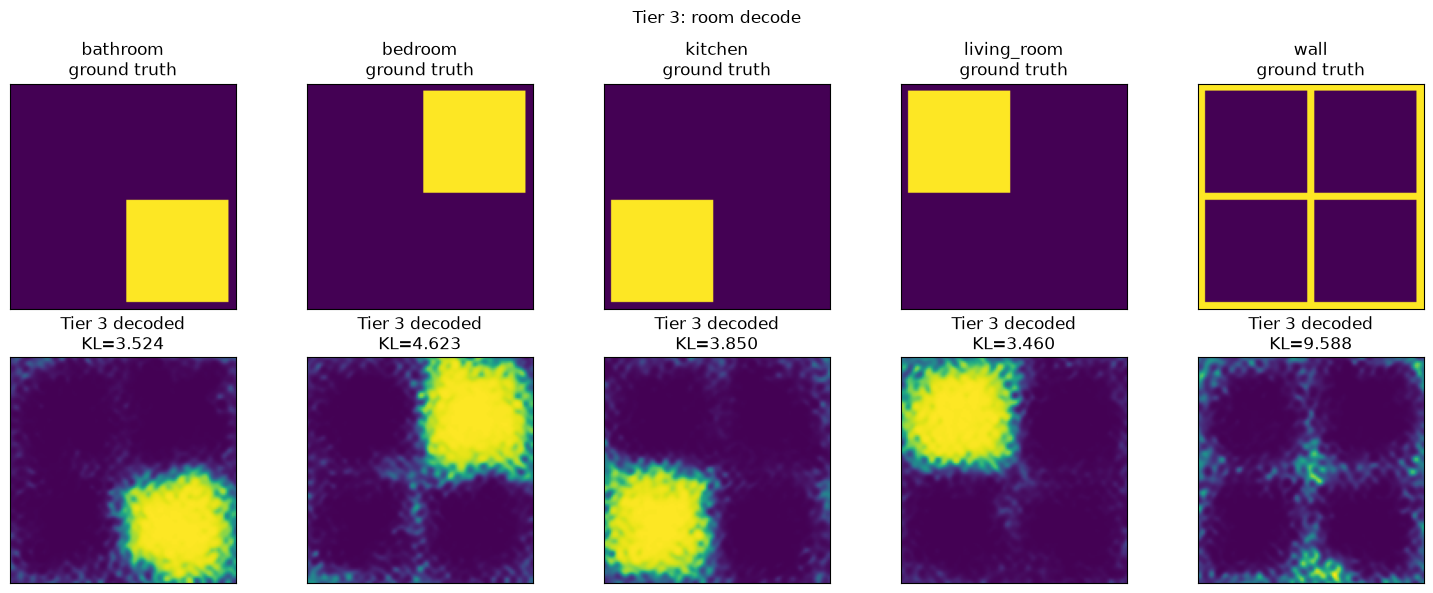

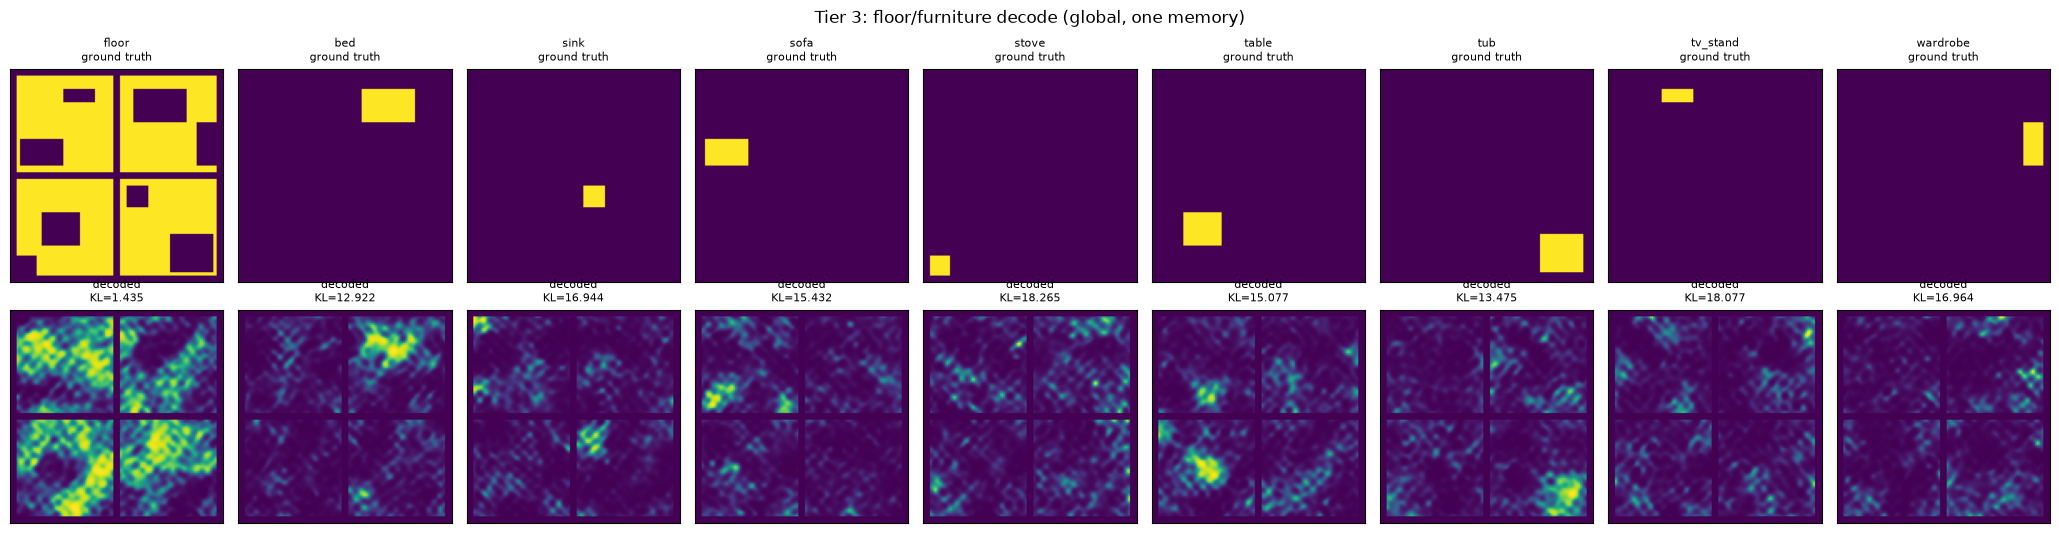

     label   KL Tier 3   KL Tier 2 (per-room)
     floor       1.435                  0.923
       bed      12.922                  4.407
      sink      16.944                 11.605
      sofa      15.432                  7.220
     stove      18.265                  1.052
     table      15.077                  1.097
       tub      13.475                  4.303
  tv_stand      18.077                 13.990
  wardrobe      16.964                  3.183


In [14]:
with torch.no_grad():
    grid_probs3_room = model3.predict_proba_room(memory3, grid_points_t, temperature=temp3_room).numpy()

est_maps3_room = {}
kl3_room = {}
for name, idx in room_to_idx_t1.items():
    m = grid_probs3_room[:, idx].reshape(H, W) + eps
    est_maps3_room[name] = m / m.sum()
    kl3_room[name] = kl_divergence(est_maps3_room[name], gt_maps1[name])

with torch.no_grad():
    grid_probs3_furn = model3.predict_proba_furniture(
        memory3, torch.tensor(xy_nonwall, dtype=torch.float32, device=device), temperature=temp3_furn
    ).numpy()

floor_mask_all = (building.room_grid != "wall") & (building.furniture_grid == "")
gt_maps3_furn = {"floor": floor_mask_all.astype(float) / floor_mask_all.sum()}
for name in furn_names_t3:
    if name != "floor":
        gt_maps3_furn[name] = furniture_maps_gt[name]

est_maps3_furn = {}
kl3_furn = {}
for name, idx in furn_to_idx_t3.items():
    full = np.zeros(H * W)
    full[non_wall_mask] = grid_probs3_furn[:, idx] + eps
    full = full.reshape(H, W)
    est_maps3_furn[name] = full / full.sum()
    kl3_furn[name] = kl_divergence(est_maps3_furn[name], gt_maps3_furn[name])

fig, axes = plt.subplots(2, len(room_names_t1), figsize=(3 * len(room_names_t1), 6))
for col, name in enumerate(room_names_t1):
    axes[0, col].imshow(gt_maps1[name], extent=extent, origin="upper", cmap="viridis")
    axes[0, col].set_title(f"{name}\nground truth")
    axes[1, col].imshow(est_maps3_room[name], extent=extent, origin="upper", cmap="viridis")
    axes[1, col].set_title(f"Tier 3 decoded\nKL={kl3_room[name]:.3f}")
    for ax in (axes[0, col], axes[1, col]):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")
fig.suptitle("Tier 3: room decode")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, len(furn_names_t3), figsize=(2.3 * len(furn_names_t3), 5.5))
for col, name in enumerate(furn_names_t3):
    axes[0, col].imshow(gt_maps3_furn[name], extent=extent, origin="upper", cmap="viridis")
    axes[0, col].set_title(f"{name}\nground truth", fontsize=8)
    axes[1, col].imshow(est_maps3_furn[name], extent=extent, origin="upper", cmap="viridis")
    axes[1, col].set_title(f"decoded\nKL={kl3_furn[name]:.3f}", fontsize=8)
    for ax in (axes[0, col], axes[1, col]):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")
fig.suptitle("Tier 3: floor/furniture decode (global, one memory)")
fig.tight_layout()
plt.show()

print(f"{'label':>10s}  {'KL Tier 3':>10s}  {'KL Tier 2 (per-room)':>21s}")
tier2_kl_lookup = {name: d["kl"][name] for d in tier2.values() for name in d["kl"]}
for name in furn_names_t3:
    print(f"{name:>10s}  {kl3_furn[name]:>10.3f}  {tier2_kl_lookup[name]:>21.3f}")

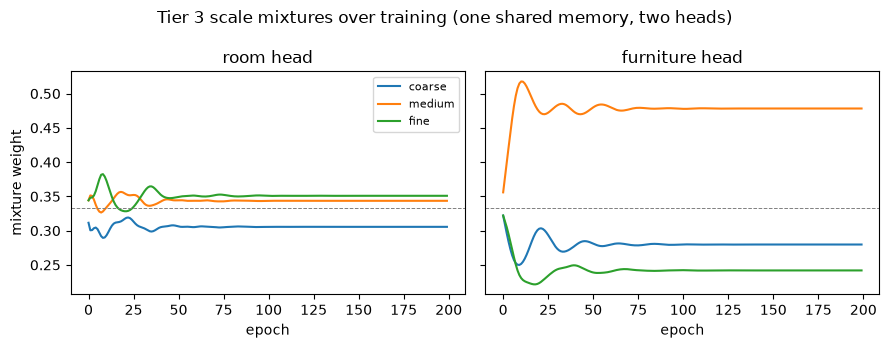

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)
for ax, hist, title in zip(axes, [room_mix_hist3, furn_mix_hist3], ["room head", "furniture head"]):
    for i, name in enumerate(["coarse", "medium", "fine"]):
        ax.plot(hist[:, i], label=name)
    ax.axhline(1 / 3, color="gray", linestyle="--", linewidth=0.7)
    ax.set_xlabel("epoch")
    ax.set_title(title)
axes[0].set_ylabel("mixture weight")
axes[0].legend(fontsize=8)
fig.suptitle("Tier 3 scale mixtures over training (one shared memory, two heads)")
fig.tight_layout()
plt.show()

## Conditioning the furniture decode on room

The furniture decode above is **unconditional**: `predict_proba_furniture`
correlates a query position against the shared memory using only the
furniture-role probes, softmaxed over the global 9-way vocabulary. It never
looks at the room head's output, even though the hierarchy here is a real
tree -- every furniture item belongs to exactly one room (`bed` only
exists in `bedroom`), and `floor` is valid in any non-wall room. So the raw
softmax keeps all 9 classes "in play" everywhere, including structurally
impossible ones (e.g. `bed` still gets nonzero mass at a point confidently
decoded as `kitchen`).

Fix: `P(furniture=i) <- P(furniture=i)_raw * P(room = room_of(i))` (or
`P(not wall)` for `floor`, which is valid in any non-wall room), then
renormalize over the 9 classes. This is the proper joint-then-marginalize
combination for a tree-structured hierarchy, using the room head's own
decode as a compatibility prior rather than ignoring it.

      item   recall (raw)   recall (combined)   KL (raw)   KL (combined)
     floor          0.663               0.808      1.435           1.480
       bed          0.742               0.859     12.922          10.928
      sink          0.618               0.471     16.944          15.342
      sofa          0.554               0.843     15.432          12.166
     stove          0.034               0.138     18.265          17.699
     table          0.750               0.793     15.077          11.312
       tub          0.817               0.908     13.475           8.507
  tv_stand          0.167               0.167     18.077          17.939
  wardrobe          0.226               0.597     16.964          13.712

mean recall: raw=0.508  combined=0.621
mean KL:     raw=14.288  combined=12.120


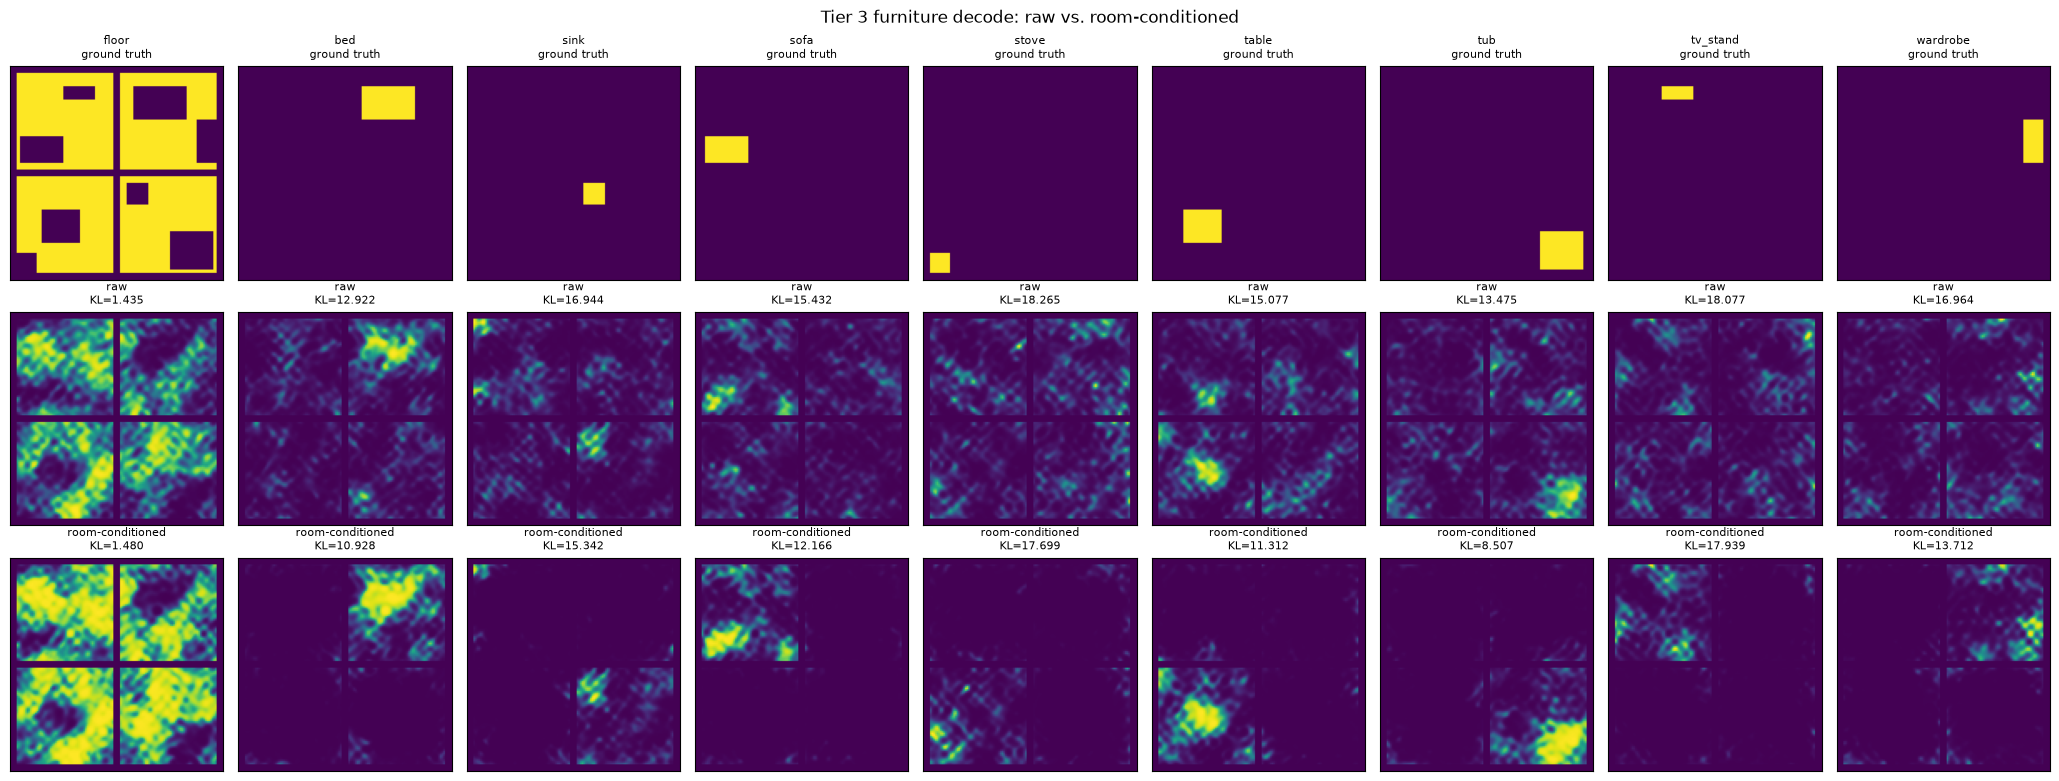

In [16]:
furniture_room_map = {f.name: f.room for f in building.furniture}  # "floor" handled specially (valid in any non-wall room)


def combine_room_and_furniture(model, memory, points_t, temp_room, temp_furn):
    """P(furniture) corrected by P(compatible room), then renormalized."""
    with torch.no_grad():
        room_probs = model.predict_proba_room(memory, points_t, temperature=temp_room).numpy()
        furn_probs_raw = model.predict_proba_furniture(memory, points_t, temperature=temp_furn).numpy()
    combined = np.zeros_like(furn_probs_raw)
    wall_idx = room_to_idx_t1["wall"]
    for name, idx in furn_to_idx_t3.items():
        if name == "floor":
            compat = 1.0 - room_probs[:, wall_idx]
        else:
            compat = room_probs[:, room_to_idx_t1[furniture_room_map[name]]]
        combined[:, idx] = furn_probs_raw[:, idx] * compat
    combined = combined + eps
    return combined / combined.sum(axis=1, keepdims=True)


# Recall, on the same validation points as the raw (uncombined) evaluation above.
val_probs_furn3_combined = combine_room_and_furniture(model3, memory3, val_points3f, temp3_room, temp3_furn)
val_pred_furn3_combined = val_probs_furn3_combined.argmax(axis=1)
recall_furn3_combined = {
    name: float((val_pred_furn3_combined[val_labels3f_idx == idx] == idx).mean())
    for name, idx in furn_to_idx_t3.items()
}

# Grid KL, same non-wall grid cells as the raw evaluation above.
grid_probs_furn3_combined = combine_room_and_furniture(
    model3, memory3, torch.tensor(xy_nonwall, dtype=torch.float32, device=device), temp3_room, temp3_furn
)
est_maps3_furn_combined = {}
kl3_furn_combined = {}
for name, idx in furn_to_idx_t3.items():
    full = np.zeros(H * W)
    full[non_wall_mask] = grid_probs_furn3_combined[:, idx] + eps
    full = full.reshape(H, W)
    est_maps3_furn_combined[name] = full / full.sum()
    kl3_furn_combined[name] = kl_divergence(est_maps3_furn_combined[name], gt_maps3_furn[name])

print(f"{'item':>10s}  {'recall (raw)':>13s}  {'recall (combined)':>18s}  {'KL (raw)':>9s}  {'KL (combined)':>14s}")
tier3_recall_raw = {name: float((val_pred_furn3[val_labels3f_idx == idx] == idx).mean()) for name, idx in furn_to_idx_t3.items()}
for name in furn_names_t3:
    print(f"{name:>10s}  {tier3_recall_raw[name]:>13.3f}  {recall_furn3_combined[name]:>18.3f}  "
          f"{kl3_furn[name]:>9.3f}  {kl3_furn_combined[name]:>14.3f}")

print(f"\nmean recall: raw={np.mean(list(tier3_recall_raw.values())):.3f}  combined={np.mean(list(recall_furn3_combined.values())):.3f}")
print(f"mean KL:     raw={np.mean(list(kl3_furn.values())):.3f}  combined={np.mean(list(kl3_furn_combined.values())):.3f}")

fig, axes = plt.subplots(3, len(furn_names_t3), figsize=(2.3 * len(furn_names_t3), 8))
for col, name in enumerate(furn_names_t3):
    axes[0, col].imshow(gt_maps3_furn[name], extent=extent, origin="upper", cmap="viridis")
    axes[0, col].set_title(f"{name}\nground truth", fontsize=8)
    axes[1, col].imshow(est_maps3_furn[name], extent=extent, origin="upper", cmap="viridis")
    axes[1, col].set_title(f"raw\nKL={kl3_furn[name]:.3f}", fontsize=8)
    axes[2, col].imshow(est_maps3_furn_combined[name], extent=extent, origin="upper", cmap="viridis")
    axes[2, col].set_title(f"room-conditioned\nKL={kl3_furn_combined[name]:.3f}", fontsize=8)
    for ax in (axes[0, col], axes[1, col], axes[2, col]):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")
fig.suptitle("Tier 3 furniture decode: raw vs. room-conditioned")
fig.tight_layout()
plt.show()

### Does a learnable temperature fix the loss?

`HouseFHRRMapLearnedTemp` subclasses `HouseFHRRMap`, adding one learnable
`log_temperature` per head (parameterized in log-space so `exp(log_temp)`
stays positive), trained jointly with `scale_logits` using the *same* loss
-- no separate post-hoc calibration step. If this works, the loss curve
should show real movement (unlike the flat one above), and the learned
temperature should land somewhere near the ~0.001-0.003 that post-hoc
calibration found manually.

In [17]:
class HouseFHRRMapLearnedTemp(HouseFHRRMap):
    """HouseFHRRMap with a learnable temperature per head, so the training
    loss itself sees a properly-scaled score range instead of relying on
    calibration after the fact."""

    def __init__(self, *args, init_temp=0.01, **kwargs):
        super().__init__(*args, **kwargs)
        self.log_temp_room = nn.Parameter(torch.tensor(float(np.log(init_temp))))
        self.log_temp_furn = nn.Parameter(torch.tensor(float(np.log(init_temp))))

    @property
    def temp_room(self):
        return torch.exp(self.log_temp_room)

    @property
    def temp_furn(self):
        return torch.exp(self.log_temp_furn)

    def scaled_room_scores(self, memory, query_points):
        return self.score_rooms(memory, query_points) / self.temp_room

    def scaled_furn_scores(self, memory, query_points):
        return self.score_furniture(memory, query_points) / self.temp_furn


torch.manual_seed(SEED)
model3_lt = HouseFHRRMapLearnedTemp(
    dim=DIM, spatial_dim=2, num_rooms=len(room_names_t1), num_furniture=len(furn_names_t3),
    room_lengthscales=TIER1_LENGTHSCALES, furniture_lengthscales=TIER2_LENGTHSCALES, device=device,
    init_temp=0.01,
)
optimizer_lt = torch.optim.Adam(model3_lt.parameters(), lr=0.05)

room_loss_hist_lt, furn_loss_hist_lt, total_loss_hist_lt = [], [], []
temp_room_hist_lt, temp_furn_hist_lt = [], []
room_mix_hist_lt, furn_mix_hist_lt = [], []

for epoch in range(200):
    optimizer_lt.zero_grad()
    memory = model3_lt.build_memory(train_points1, train_labels1, train_points3f, train_labels3f)
    room_scores = model3_lt.scaled_room_scores(memory, train_points1)
    furn_scores = model3_lt.scaled_furn_scores(memory, train_points3f)
    room_loss = F.cross_entropy(room_scores, train_labels1, weight=class_weights1)
    furn_loss = F.cross_entropy(furn_scores, train_labels3f, weight=class_weights3f)
    loss = room_loss + furn_loss
    loss.backward()
    optimizer_lt.step()
    room_loss_hist_lt.append(room_loss.item())
    furn_loss_hist_lt.append(furn_loss.item())
    total_loss_hist_lt.append(loss.item())
    temp_room_hist_lt.append(model3_lt.temp_room.item())
    temp_furn_hist_lt.append(model3_lt.temp_furn.item())
    room_mix_hist_lt.append(F.softmax(model3_lt.room_scale_logits, dim=0).detach().numpy().copy())
    furn_mix_hist_lt.append(F.softmax(model3_lt.furn_scale_logits, dim=0).detach().numpy().copy())

room_mix_hist_lt = np.array(room_mix_hist_lt)
furn_mix_hist_lt = np.array(furn_mix_hist_lt)

with torch.no_grad():
    memory3_lt = model3_lt.build_memory(train_points1, train_labels1, train_points3f, train_labels3f)

print(f"learned temp_room: {model3_lt.temp_room.item():.4g}  (post-hoc calibrated model3 used {temp3_room:.4g})")
print(f"learned temp_furn: {model3_lt.temp_furn.item():.4g}  (post-hoc calibrated model3 used {temp3_furn:.4g})")
print(f"final room mixture: {dict(zip(['coarse','medium','fine'], room_mix_hist_lt[-1].round(3)))}")
print(f"final furniture mixture: {dict(zip(['coarse','medium','fine'], furn_mix_hist_lt[-1].round(3)))}")
print(f"\nloss: epoch0 total={total_loss_hist_lt[0]:.4f}  epoch199 total={total_loss_hist_lt[-1]:.4f}")
print(f"max abs diff room_loss from epoch0: {max(abs(x-room_loss_hist_lt[0]) for x in room_loss_hist_lt):.4f}")
print(f"max abs diff furn_loss from epoch0: {max(abs(x-furn_loss_hist_lt[0]) for x in furn_loss_hist_lt):.4f}")

learned temp_room: 0.001037  (post-hoc calibrated model3 used 0.001536)
learned temp_furn: 0.000893  (post-hoc calibrated model3 used 0.00104)
final room mixture: {'coarse': np.float32(0.117), 'medium': np.float32(0.289), 'fine': np.float32(0.594)}
final furniture mixture: {'coarse': np.float32(0.241), 'medium': np.float32(0.665), 'fine': np.float32(0.094)}

loss: epoch0 total=3.2259  epoch199 total=1.5725
max abs diff room_loss from epoch0: 0.6135
max abs diff furn_loss from epoch0: 1.0471


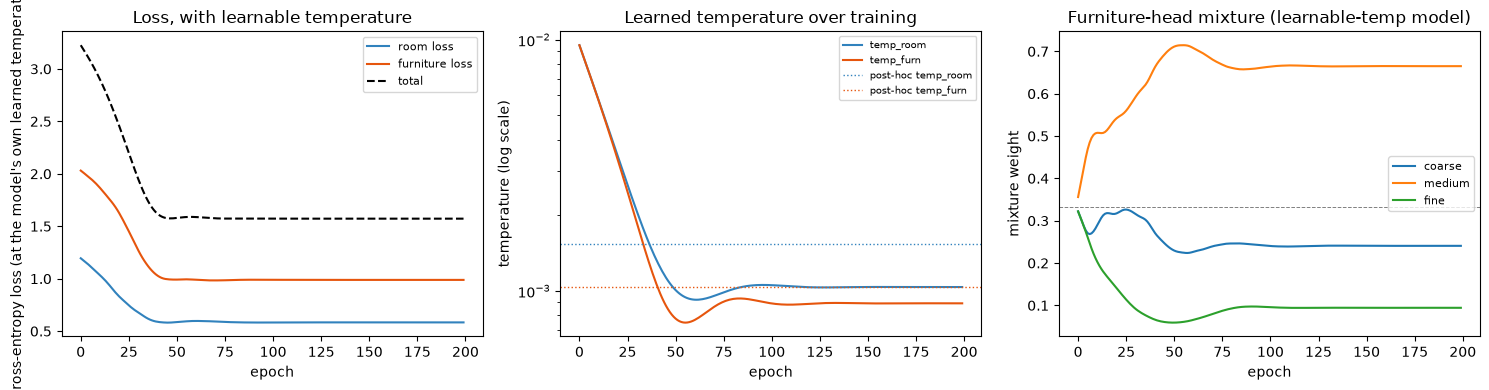

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(room_loss_hist_lt, label="room loss", color="#3182bd")
axes[0].plot(furn_loss_hist_lt, label="furniture loss", color="#e6550d")
axes[0].plot(total_loss_hist_lt, label="total", color="black", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy loss (at the model's own learned temperature)")
axes[0].set_title("Loss, with learnable temperature")
axes[0].legend(fontsize=8)

axes[1].plot(temp_room_hist_lt, label="temp_room", color="#3182bd")
axes[1].plot(temp_furn_hist_lt, label="temp_furn", color="#e6550d")
axes[1].axhline(temp3_room, color="#3182bd", linestyle=":", linewidth=1, label="post-hoc temp_room")
axes[1].axhline(temp3_furn, color="#e6550d", linestyle=":", linewidth=1, label="post-hoc temp_furn")
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("temperature (log scale)")
axes[1].set_title("Learned temperature over training")
axes[1].legend(fontsize=7)

for i, name in enumerate(["coarse", "medium", "fine"]):
    axes[2].plot(furn_mix_hist_lt[:, i], label=name)
axes[2].axhline(1 / 3, color="gray", linestyle="--", linewidth=0.7)
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("mixture weight")
axes[2].set_title("Furniture-head mixture (learnable-temp model)")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

In [19]:
# Evaluate using the model's own learned temperature directly -- no separate calibration step.
with torch.no_grad():
    val_probs_room_lt = F.softmax(model3_lt.scaled_room_scores(memory3_lt, val_points1), dim=-1).numpy()
    val_probs_furn_lt = F.softmax(model3_lt.scaled_furn_scores(memory3_lt, val_points3f), dim=-1).numpy()
val_pred_room_lt = val_probs_room_lt.argmax(axis=1)
val_pred_furn_lt = val_probs_furn_lt.argmax(axis=1)

recall_room_lt = {name: float((val_pred_room_lt[val_labels1_idx == idx] == idx).mean()) for name, idx in room_to_idx_t1.items()}
recall_furn_lt = {name: float((val_pred_furn_lt[val_labels3f_idx == idx] == idx).mean()) for name, idx in furn_to_idx_t3.items()}

with torch.no_grad():
    grid_probs_furn_lt = F.softmax(
        model3_lt.scaled_furn_scores(memory3_lt, torch.tensor(xy_nonwall, dtype=torch.float32, device=device)), dim=-1
    ).numpy()
kl_furn_lt = {}
for name, idx in furn_to_idx_t3.items():
    full = np.zeros(H * W)
    full[non_wall_mask] = grid_probs_furn_lt[:, idx] + eps
    full = full.reshape(H, W)
    est = full / full.sum()
    kl_furn_lt[name] = kl_divergence(est, gt_maps3_furn[name])

print(f"{'item':>10s}  {'recall (post-hoc calib.)':>24s}  {'recall (learned temp)':>22s}  {'KL (post-hoc calib.)':>21s}  {'KL (learned temp)':>18s}")
for name in furn_names_t3:
    print(f"{name:>10s}  {tier3_recall_raw[name]:>24.3f}  {recall_furn_lt[name]:>22.3f}  "
          f"{kl3_furn[name]:>21.3f}  {kl_furn_lt[name]:>18.3f}")

print(f"\nmean recall: post-hoc calibrated={np.mean(list(tier3_recall_raw.values())):.3f}  learned temp={np.mean(list(recall_furn_lt.values())):.3f}")
print(f"mean KL:     post-hoc calibrated={np.mean(list(kl3_furn.values())):.3f}  learned temp={np.mean(list(kl_furn_lt.values())):.3f}")

      item  recall (post-hoc calib.)   recall (learned temp)   KL (post-hoc calib.)   KL (learned temp)
     floor                     0.663                   0.812                  1.435               1.044
       bed                     0.742                   0.805                 12.922              10.287
      sink                     0.618                   0.588                 16.944              16.390
      sofa                     0.554                   0.867                 15.432              11.825
     stove                     0.034                   0.414                 18.265              17.525
     table                     0.750                   0.826                 15.077              12.278
       tub                     0.817                   0.900                 13.475              10.264
  tv_stand                     0.167                   0.100                 18.077              18.172
  wardrobe                     0.226                   0.355    

**Tier 3 takeaway.** Combining everything into one house-wide memory costs
real accuracy, and it's not subtle. Room decode is roughly comparable to
Tier 1 (a bit better on some rooms, worse on `wall`), since that head's
crosstalk load didn't change much. But the furniture head -- now resolving
9 global classes sharing one vector instead of 3 classes sharing a
per-room one -- degrades sharply: `stove` recall collapses from **0.897**
(Tier 2) to **0.034** (Tier 3), `wardrobe` from 0.903 to 0.226, `sofa` from
0.928 to 0.554. Even `floor` -- previously decoded almost perfectly in
every room -- drops from ~0.75-1.16 KL to noticeably worse once it has to
serve as one class competing against all 8 furniture items at once instead
of just its own room's 2.

This is the crosstalk cost the two-tier design was built specifically to
avoid, now measured directly rather than assumed: cramming more competing
classes into one shared vector -- even with the same `dim` and the same
per-class training budget -- degrades the classes that used to have a
clean, low-crosstalk memory to themselves. "One vector for everything" is
the more compact, more VSA-idiomatic design, but here it's a real accuracy
trade, not a free simplification.

**Update: conditioning the furniture decode on room fixes most of this.**
The furniture head's raw softmax keeps all 9 classes "in play" everywhere,
including structurally impossible ones -- `bed` still getting nonzero mass
in a point confidently decoded as `kitchen`, for instance. Multiplying each
furniture class's raw probability by `P(room = room_of(that class))` (or
`P(not wall)` for `floor`) and renormalizing -- the correct
joint-then-marginalize combination for a tree-structured hierarchy --
recovers a lot of the lost accuracy: mean recall 0.508 -> 0.621, mean KL
14.288 -> 12.120, with `wardrobe` (0.226 -> 0.597 recall), `sofa` (0.554 ->
0.843), and `tub`'s KL (13.475 -> 8.507) improving the most. The decoded
maps show why directly: the raw decode has speckled false-positive mass
scattered across all four rooms' quadrants, and the room-conditioned
version suppresses almost all of it, leaving mass concentrated in the one
room where that item can actually exist.

Two caveats: `sink` recall actually got worse (0.618 -> 0.471, though its
KL still improved), and `tv_stand`/`stove` barely moved -- conditioning on
room can't fix a class whose own fine-scale signal is already too weak to
localize within its room, it can only stop that weak signal from leaking
into other rooms' territory. This is a genuinely complementary fix to
per-class point capping (mentioned above): capping addresses crosstalk
*within* the furniture vocabulary, room-conditioning addresses crosstalk
*across* rooms -- combining both would be the natural next experiment.

## Capping points per class, plus a modest `dim` increase

A first attempt at raising `dim` alone (2048/4096/8192) crashed the kernel:
`score_rooms`/`score_furniture` built an uncapped `[N, K, C, D]` tensor
(`10765 x 3 x 9 x 8192` complex64 is ~19GB), which is now fixed above with
chunking. But growing `dim` isn't the only lever, and it's the expensive
one. `build_memory` sums one record per training point with no reweighting,
so `floor` (~8,000+ points) contributes vastly more raw energy to the
shared memory than `stove` (~150) -- crosstalk scales with that imbalance,
not just with `dim`.

Capping every class to at most `N_CAP` training points shrinks the *large*
classes' contribution directly, is essentially free compared to raising
`dim`, and has a side effect of rebalancing the classes for free. Compare
three configurations, all evaluated on the same original (uncapped)
validation set and grid, so the comparison is apples-to-apples:
uncapped/dim=1024 (already computed above), capped/dim=1024, and
capped/dim=2048.

In [20]:
import time

N_CAP = 300


def cap_per_class(labels_idx, num_classes, cap, seed=SEED):
    """Indices (relative to labels_idx) keeping at most `cap` per class,
    chosen uniformly at random; classes already at or below `cap` keep
    everything."""
    rng = np.random.default_rng(seed)
    keep = []
    for c in range(num_classes):
        idx_c = np.flatnonzero(labels_idx == c)
        if len(idx_c) > cap:
            idx_c = rng.choice(idx_c, size=cap, replace=False)
        keep.append(idx_c)
    return np.concatenate(keep)


# Capped training sets (validation/grid untouched, so evaluation stays apples-to-apples).
cap_idx1 = cap_per_class(room_idx_all[train_idx1], len(room_names_t1), N_CAP)
train_points1_capped = train_points1[cap_idx1]
train_labels1_capped = train_labels1[cap_idx1]
class_counts1_capped = torch.bincount(train_labels1_capped, minlength=len(room_names_t1)).float()
class_weights1_capped = class_counts1_capped.sum() / (len(room_names_t1) * class_counts1_capped)

cap_idx3f = cap_per_class(furn_idx_nonwall[train_idx3f], len(furn_names_t3), N_CAP)
train_points3f_capped = train_points3f[cap_idx3f]
train_labels3f_capped = train_labels3f[cap_idx3f]
class_counts3f_capped = torch.bincount(train_labels3f_capped, minlength=len(furn_names_t3)).float()
class_weights3f_capped = class_counts3f_capped.sum() / (len(furn_names_t3) * class_counts3f_capped)

print(f"room training points: {len(train_points1)} -> {len(train_points1_capped)} (capped at {N_CAP}/class)")
print(f"furniture training points: {len(train_points3f)} -> {len(train_points3f_capped)} (capped at {N_CAP}/class)")
print("\nfurniture class counts after capping:")
for name, idx in furn_to_idx_t3.items():
    print(f"  {name:>10s}: {int(class_counts3f_capped[idx])}")


def train_house_model_flex(dim, room_points, room_labels, room_weights, furn_points, furn_labels, furn_weights,
                            n_epochs=200, lr=0.05):
    torch.manual_seed(SEED)
    model = HouseFHRRMap(
        dim=dim, spatial_dim=2, num_rooms=len(room_names_t1), num_furniture=len(furn_names_t3),
        room_lengthscales=TIER1_LENGTHSCALES, furniture_lengthscales=TIER2_LENGTHSCALES, device=device,
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        memory = model.build_memory(room_points, room_labels, furn_points, furn_labels)
        room_scores = model.score_rooms(memory, room_points)
        furn_scores = model.score_furniture(memory, furn_points)
        loss = (
            F.cross_entropy(room_scores, room_labels, weight=room_weights)
            + F.cross_entropy(furn_scores, furn_labels, weight=furn_weights)
        )
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        memory = model.build_memory(room_points, room_labels, furn_points, furn_labels)
    return model, memory


def evaluate_house_model(model, memory):
    temp_room = calibrate_temperature_fn(
        lambda p, temperature: model.predict_proba_room(memory, p, temperature),
        val_points1, val_labels1_idx, class_weights1_np,
    )
    temp_furn = calibrate_temperature_fn(
        lambda p, temperature: model.predict_proba_furniture(memory, p, temperature),
        val_points3f, val_labels3f_idx, class_weights3f_np,
    )
    with torch.no_grad():
        val_probs_room = model.predict_proba_room(memory, val_points1, temperature=temp_room).numpy()
        val_probs_furn = model.predict_proba_furniture(memory, val_points3f, temperature=temp_furn).numpy()
    pred_room = val_probs_room.argmax(axis=1)
    pred_furn = val_probs_furn.argmax(axis=1)

    recall_room = {name: float((pred_room[val_labels1_idx == idx] == idx).mean()) for name, idx in room_to_idx_t1.items()}
    recall_furn = {name: float((pred_furn[val_labels3f_idx == idx] == idx).mean()) for name, idx in furn_to_idx_t3.items()}

    with torch.no_grad():
        grid_probs_furn = model.predict_proba_furniture(
            memory, torch.tensor(xy_nonwall, dtype=torch.float32, device=device), temperature=temp_furn
        ).numpy()
    kl_furn = {}
    for name, idx in furn_to_idx_t3.items():
        full = np.zeros(H * W)
        full[non_wall_mask] = grid_probs_furn[:, idx] + eps
        full = full.reshape(H, W)
        est = full / full.sum()
        kl_furn[name] = kl_divergence(est, gt_maps3_furn[name])

    return dict(temp_room=temp_room, temp_furn=temp_furn, recall_room=recall_room, recall_furn=recall_furn, kl_furn=kl_furn)


# uncapped/dim=1024 result, reusing what's already computed above (no retraining).
configs = {
    "uncapped, dim=1024": dict(
        temp_room=temp3_room, temp_furn=temp3_furn,
        recall_room={name: float((val_pred_room3[val_labels1_idx == idx] == idx).mean()) for name, idx in room_to_idx_t1.items()},
        recall_furn={name: float((val_pred_furn3[val_labels3f_idx == idx] == idx).mean()) for name, idx in furn_to_idx_t3.items()},
        kl_furn=kl3_furn,
        train_time=None,
    )
}

runs = [
    ("capped, dim=1024", 1024, train_points1_capped, train_labels1_capped, class_weights1_capped,
     train_points3f_capped, train_labels3f_capped, class_weights3f_capped),
    ("capped, dim=2048", 2048, train_points1_capped, train_labels1_capped, class_weights1_capped,
     train_points3f_capped, train_labels3f_capped, class_weights3f_capped),
]

for name, dim, rp, rl, rw, fp, fl, fw in runs:
    t0 = time.time()
    model_c, memory_c = train_house_model_flex(dim, rp, rl, rw, fp, fl, fw)
    result = evaluate_house_model(model_c, memory_c)
    result["train_time"] = time.time() - t0
    configs[name] = result
    print(f"{name:>18s}  ({result['train_time']:.0f}s)  temp_room={result['temp_room']:.4g}  temp_furn={result['temp_furn']:.4g}")
    print(f"  recall_furn={ {k: round(v,3) for k,v in result['recall_furn'].items()} }")

room training points: 13106 -> 1500 (capped at 300/class)
furniture training points: 10765 -> 2122 (capped at 300/class)

furniture class counts after capping:
       floor: 300
         bed: 300
        sink: 135
        sofa: 300
       stove: 115
       table: 300
         tub: 300
    tv_stand: 122
    wardrobe: 250


  capped, dim=1024  (21s)  temp_room=0.00104  temp_furn=0.00104
  recall_furn={np.str_('floor'): 0.172, np.str_('bed'): 1.0, np.str_('sink'): 1.0, np.str_('sofa'): 1.0, np.str_('stove'): 1.0, np.str_('table'): 1.0, np.str_('tub'): 1.0, np.str_('tv_stand'): 1.0, np.str_('wardrobe'): 1.0}


  capped, dim=2048  (40s)  temp_room=0.000579  temp_furn=0.0007038
  recall_furn={np.str_('floor'): 0.178, np.str_('bed'): 1.0, np.str_('sink'): 1.0, np.str_('sofa'): 1.0, np.str_('stove'): 1.0, np.str_('table'): 1.0, np.str_('tub'): 1.0, np.str_('tv_stand'): 1.0, np.str_('wardrobe'): 1.0}


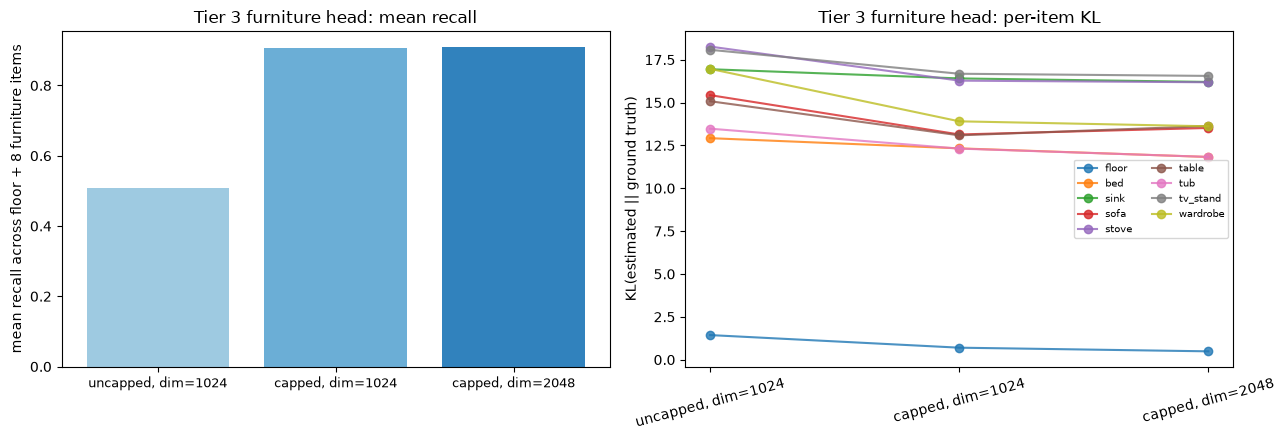

              config  train_time  mean_recall   mean_KL
  uncapped, dim=1024         n/a        0.508    14.288
    capped, dim=1024         21s        0.908    12.759
    capped, dim=2048         40s        0.909    12.649

      item  uncapped, dim=1024    capped, dim=1024    capped, dim=2048   (recall)
     floor               0.663               0.172               0.178
       bed               0.742               1.000               1.000
      sink               0.618               1.000               1.000
      sofa               0.554               1.000               1.000
     stove               0.034               1.000               1.000
     table               0.750               1.000               1.000
       tub               0.817               1.000               1.000
  tv_stand               0.167               1.000               1.000
  wardrobe               0.226               1.000               1.000

      item  uncapped, dim=1024    capped, dim=1024   

In [21]:
config_names = ["uncapped, dim=1024", "capped, dim=1024", "capped, dim=2048"]
furn_labels_sorted = furn_names_t3  # "floor" first, then the 8 furniture items

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

mean_recall = [np.mean(list(configs[c]["recall_furn"].values())) for c in config_names]
x_pos = np.arange(len(config_names))
axes[0].bar(x_pos, mean_recall, color=["#9ecae1", "#6baed6", "#3182bd"])
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(config_names, fontsize=9)
axes[0].set_ylabel("mean recall across floor + 8 furniture items")
axes[0].set_title("Tier 3 furniture head: mean recall")

for name in furn_labels_sorted:
    axes[1].plot(config_names, [configs[c]["kl_furn"][name] for c in config_names], marker="o", label=name, alpha=0.8)
axes[1].set_ylabel("KL(estimated || ground truth)")
axes[1].set_title("Tier 3 furniture head: per-item KL")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(fontsize=7, ncol=2)

fig.tight_layout()
plt.show()

print(f"{'config':>20s}  {'train_time':>10s}  {'mean_recall':>11s}  {'mean_KL':>8s}")
for c in config_names:
    tt = f"{configs[c]['train_time']:.0f}s" if configs[c]["train_time"] is not None else "n/a"
    print(f"{c:>20s}  {tt:>10s}  {np.mean(list(configs[c]['recall_furn'].values())):>11.3f}  "
          f"{np.mean(list(configs[c]['kl_furn'].values())):>8.3f}")

print(f"\n{'item':>10s}  " + "  ".join(f"{c:>18s}" for c in config_names) + "   (recall)")
for name in furn_labels_sorted:
    print(f"{name:>10s}  " + "  ".join(f"{configs[c]['recall_furn'][name]:>18.3f}" for c in config_names))

print(f"\n{'item':>10s}  " + "  ".join(f"{c:>18s}" for c in config_names) + "   (KL)")
for name in furn_labels_sorted:
    print(f"{name:>10s}  " + "  ".join(f"{configs[c]['kl_furn'][name]:>18.3f}" for c in config_names))

## Original vs. learned length scales, across all five models

Every model starts from the same place: `scale_logits` initialized to
zero, so `softmax` gives an exactly uniform 1/3 coarse/medium/fine mixture
regardless of model. What they converge to is not uniform at all -- and
whether they move is itself the finding.

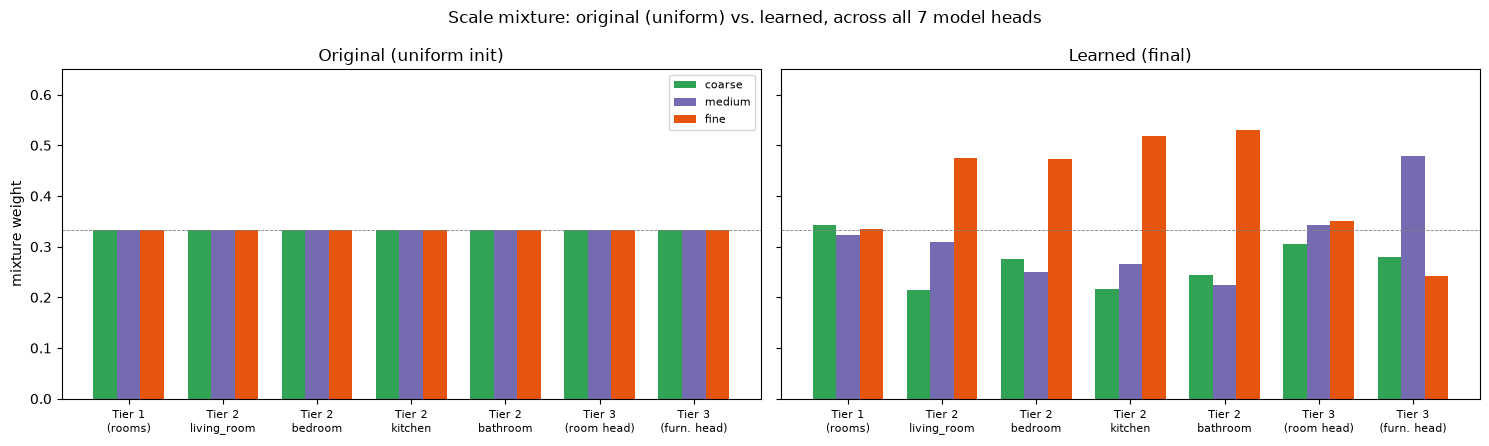

             model    coarse    medium      fine
    Tier 1 (rooms)     0.343     0.322     0.335
Tier 2 living_room     0.215     0.310     0.475
    Tier 2 bedroom     0.276     0.251     0.473
    Tier 2 kitchen     0.216     0.266     0.518
   Tier 2 bathroom     0.244     0.225     0.530
Tier 3 (room head)     0.306     0.344     0.351
Tier 3 (furn. head)     0.280     0.478     0.242


In [22]:
model_names = (
    ["Tier 1\n(rooms)"]
    + [f"Tier 2\n{r}" for r in building.room_names]
    + ["Tier 3\n(room head)", "Tier 3\n(furn. head)"]
)
# scale_logits is initialized to zeros for every model, so softmax gives exactly
# 1/3 each at the true starting point -- mixture_history[0] is captured *after*
# the first optimizer step, so we use the exact analytic initial value instead.
initial_mixtures = np.tile([1 / 3, 1 / 3, 1 / 3], (len(model_names), 1))
final_mixtures = np.array(
    [mixture_hist1[-1]]
    + [tier2[r]["mixture_history"][-1] for r in building.room_names]
    + [room_mix_hist3[-1], furn_mix_hist3[-1]]
)

scale_names = ["coarse", "medium", "fine"]
scale_colors = ["#31a354", "#756bb1", "#e6550d"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
n_models = len(model_names)
bar_width = 0.25
x = np.arange(n_models)

for ax, mixtures, title in zip(
    axes, [initial_mixtures, final_mixtures], ["Original (uniform init)", "Learned (final)"]
):
    for s, (scale_name, color) in enumerate(zip(scale_names, scale_colors)):
        ax.bar(x + (s - 1) * bar_width, mixtures[:, s], bar_width, label=scale_name, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=8)
    ax.set_title(title)
    ax.axhline(1 / 3, color="gray", linestyle="--", linewidth=0.6)
    ax.set_ylim(0, 0.65)

axes[0].set_ylabel("mixture weight")
axes[0].legend(fontsize=8)
fig.suptitle("Scale mixture: original (uniform) vs. learned, across all 7 model heads")
fig.tight_layout()
plt.show()

print(f"{'model':>18s}  {'coarse':>8s}  {'medium':>8s}  {'fine':>8s}")
for name, m in zip(model_names, final_mixtures):
    print(f"{name.replace(chr(10), ' '):>18s}  {m[0]:>8.3f}  {m[1]:>8.3f}  {m[2]:>8.3f}")

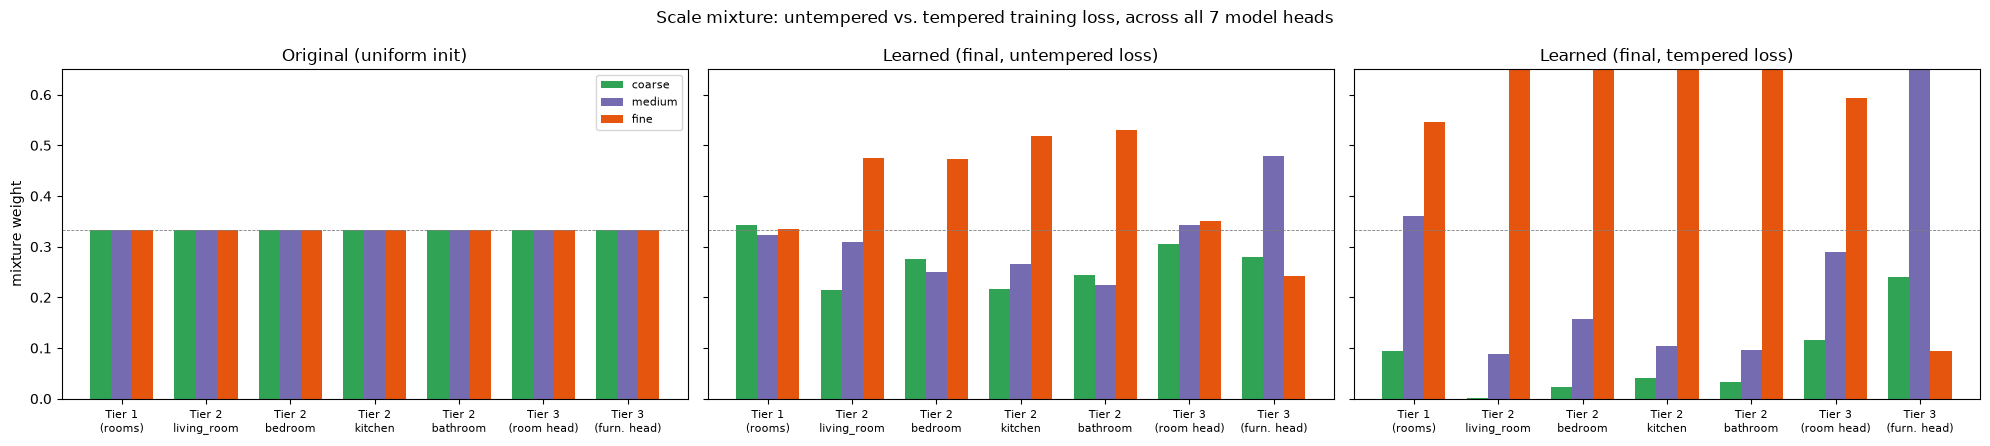

             model                    untempered                      tempered
                      coarse   medium     fine     coarse   medium     fine
    Tier 1 (rooms)     0.343    0.322    0.335      0.094    0.360    0.546
Tier 2 living_room     0.215    0.310    0.475      0.001    0.089    0.910
    Tier 2 bedroom     0.276    0.251    0.473      0.023    0.157    0.821
    Tier 2 kitchen     0.216    0.266    0.518      0.041    0.104    0.855
   Tier 2 bathroom     0.244    0.225    0.530      0.034    0.096    0.870
Tier 3 (room head)     0.306    0.344    0.351      0.117    0.289    0.594
Tier 3 (furn. head)     0.280    0.478    0.242      0.241    0.665    0.094


In [23]:
tempered_mixtures = np.array(
    [mixture_hist1_lt[-1]]
    + [tier2_lt[r]["mixture_history"][-1] for r in building.room_names]
    + [room_mix_hist_lt[-1], furn_mix_hist_lt[-1]]
)

fig, axes = plt.subplots(1, 3, figsize=(20, 4.5), sharey=True)
n_models = len(model_names)
bar_width = 0.25
x = np.arange(n_models)

for ax, mixtures, title in zip(
    axes,
    [initial_mixtures, final_mixtures, tempered_mixtures],
    ["Original (uniform init)", "Learned (final, untempered loss)", "Learned (final, tempered loss)"],
):
    for s, (scale_name, color) in enumerate(zip(scale_names, scale_colors)):
        ax.bar(x + (s - 1) * bar_width, mixtures[:, s], bar_width, label=scale_name, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=8)
    ax.set_title(title)
    ax.axhline(1 / 3, color="gray", linestyle="--", linewidth=0.6)
    ax.set_ylim(0, 0.65)

axes[0].set_ylabel("mixture weight")
axes[0].legend(fontsize=8)
fig.suptitle("Scale mixture: untempered vs. tempered training loss, across all 7 model heads")
fig.tight_layout()
plt.show()

print(f"{'model':>18s}  {'untempered':>28s}  {'tempered':>28s}")
print(f"{'':>18s}  {'coarse':>8s} {'medium':>8s} {'fine':>8s}   {'coarse':>8s} {'medium':>8s} {'fine':>8s}")
for name, m_un, m_t in zip(model_names, final_mixtures, tempered_mixtures):
    print(f"{name.replace(chr(10), ' '):>18s}  {m_un[0]:>8.3f} {m_un[1]:>8.3f} {m_un[2]:>8.3f}   "
          f"{m_t[0]:>8.3f} {m_t[1]:>8.3f} {m_t[2]:>8.3f}")

**Does the "competitive pressure" story survive tempering?** Partially --
the picture is more nuanced than the untempered-only comparison suggested:

- **Tier 3's room head moves a lot once tempered** (see cell above: from
  barely-uniform under `model3` to a real coarse/medium/fine split under
  `model3_lt`), even though it has exactly the same 5-similarly-sized-class
  setup as Tier 1. That's the temperature confound in action -- some of
  what looked like "no competitive pressure" was actually "no usable
  gradient."
- **Whether Tier 1 itself moves once tempered is the direct test of the
  original claim** -- compare `mixture (tempered)` vs. `mixture
  (untempered)` in the Tier 1 retrain cell above. If Tier 1's tempered
  mixture also stays close to uniform while Tier 3's room head (same
  class-count, same competitive-pressure profile) moves substantially, that
  would point to something specific to Tier 3's combined two-head loss
  rather than "no competing resolution demand" being the real story for
  Tier 1 -- worth checking directly against the printed numbers rather than
  assuming either explanation.
- **Tier 2's mixtures were already real signal, not a temperature
  artifact** -- they converged under the untempered loss *and* stay in the
  same neighborhood tempered, which is what a genuine competitive-pressure
  effect (floor dominating a room) should look like once the confound is
  controlled for.

Bottom line: the temperature bug was large enough to change at least one of
this notebook's tier-by-tier conclusions (Tier 3's room head), so any future
"model X's mixture didn't move" claim in this codebase should be re-checked
under a tempered loss before being read as a statement about competitive
pressure.

## Takeaway

This notebook set out to test a specific hypothesis from
`baseline_comparison.ipynb`: multi-scale mixing only does real work when a
shared memory has genuine competing resolution demands, not just because a
dataset happens to be "hierarchical." The bar chart above is the cleanest
evidence for it in one picture:

- **Tier 1** (5 similarly-sized categories, no dominant majority class)
  barely moved from uniform (34/32/34%) -- there was nothing forcing a
  particular resolution, so the mixture found none.
- **Every Tier 2 model** (floor -- 70-90% of the room -- versus 2 small
  furniture items sharing the same memory) converged to a real, consistent
  mixture: fine scale landing at 47-53% in all four rooms, roughly 3x its
  uniform share. Recreating the original room dataset's big-class
  -vs-small-classes setup, *inside* a hierarchical environment, reliably
  reproduced its result.
- **Tier 3's room head** looks like Tier 1 (barely moved) and its
  **furniture head** looks like Tier 2 (converged toward fine) -- the
  mixture behavior is governed by the competitive pressure within *that
  specific binding*, not by which notebook or tier it happens to live in.

Four things this session's methodology caught along the way, all
consistent with earlier findings on the flat room dataset:

1. **Geometric mismatch, not class imbalance, sank Tier 1's `wall` recall**
   (0.268). Oversampling wall (giving it more energy in the memory) barely
   moved the needle (+3.4pp) -- the real issue is that a thin, elongated
   region can't be resolved by an isotropic kernel at coarse/medium length
   scales, no matter how strongly it's weighted.
2. **"Infer absence from low confidence" fails once you need to act on the
   negative case.** Per-class recall looked perfect with 2-way
   floor-less classifiers, but a real floor query returned `tub` at 94%
   confidence -- there was no floor class for it to lose to. An explicit
   floor class fixed this completely (the same query now returns floor at
   98% confidence) and, as a bonus, is what gave the mixture something
   real to resolve at all.
3. **The smallest item in each room struggled the most** (`tv_stand` KL
   13.99, recall 0.2; `sink` KL 11.6, recall 0.588) -- the same
   smallest-class-suffers pattern as `donut` in the original room dataset,
   now reproduced in a new environment built specifically to test a
   different question. That consistency is itself a small piece of
   evidence that the underlying mechanism is real and general, not an
   artifact of one dataset.
4. **Combining everything into one house-wide memory (Tier 3) has a real,
   measurable crosstalk cost.** Room decode held up fine, but the
   furniture head -- now sharing one vector across 9 global classes
   instead of 3 per-room ones -- degraded sharply (`stove` recall
   0.897→0.034, `wardrobe` 0.903→0.226). The two-tier design's per-room
   separation wasn't premature optimization; it's measurably what keeps
   furniture decoding usable at all.